In [10]:
#settings
%load_ext autoreload
%autoreload 2
try:
  import google.colab
  in_colab = True
except:
  in_colab = False
print(f'Session is in colab: {in_colab}')
#installs (for colab only, run this once)
if in_colab:
    ! git clone https://github.com/GreggHeller1/PMT_linearization.git

#local imports
#cwd if in colab for imports to work
if in_colab:
    %cd /content/PMT_linearization
    
from src import data_io as io
from src import plotting as plot
from src import computation as comp
from src import main
#from src import config as gcfg

if in_colab:
    %cd /content/PMT_linearization/scripts
    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Session is in colab: False


In [11]:
import os
import pandas as pd
from glob import glob
import numpy as np
from matplotlib import pyplot as plt
import re

from scipy.ndimage import shift
from scipy.ndimage import gaussian_filter

from skimage.registration import phase_cross_correlation
from sklearn.manifold import TSNE

from itertools import combinations
from scipy.linalg import qr




In [36]:

#data_dir = r"E:\MIT Dropbox\Greggory Heller\unmixing_coefficients\2P3_excitation_only_3red"
#data_dir = r"E:\MIT Dropbox\Greggory Heller\unmixing_coefficients\2P3_all_May_3red"
#data_dir = r"E:\MIT Dropbox\Greggory Heller\unmixing_coefficients\2P3_excitation_only_3red_June"
#data_dir = r"E:\MIT Dropbox\Greggory Heller\unmixing_coefficients\may2025_3red_1140nm"
#data_dir = r"E:\MIT Dropbox\Greggory Heller\unmixing_coefficients\june2025_3red_single_images"
data_dir = r"E:\MIT Dropbox\Greggory Heller\unmixing_coefficients\june20250619_excitationOnly_3red_single_images"
os.path.exists(data_dir)

flourophore_names = os.listdir(data_dir)
flourophore_names = [filename.split('_')[0] for filename in flourophore_names]# if 'filt' in filename.lower()]
print(flourophore_names)


    

['channel', 'mCherry', 'mNeptune', 'tdTomato']


In [37]:

fp_dict = {}
for dirname in os.listdir(data_dir):
    fp_dir = os.path.join(data_dir, dirname)
    if os.path.isdir(fp_dir):
        flourophore_name = dirname.split('_')[0]
        image_dirnames = os.listdir(fp_dir)
        image_names = [image_dirname.split('-')[0] for image_dirname in image_dirnames]
        fp_dict[flourophore_name] = image_names

common_images = set()
for fp, image_names_list in fp_dict.items():
    if not(common_images):
        common_images = set(image_names_list)
    else:
        common_images = common_images & set(image_names_list)
        
    
print(common_images)    

{'BR2EmFilt_800nm_128poc_z0_650pmt', 'BR2EmFilt_1240nm_377poc_z20_650pmt', 'BR2EmFilt_1080nm_230poc_z13_650pmt', 'BR2EmFilt_1040nm_182poc_z11_650pmt', 'BR2EmFilt_1080nm_230poc_z20_650pmt', 'BR2EmFilt_1180nm_245poc_z17_650pmt'}


In [38]:
conditions_dict = {
    'filters': [],
    'exc_wavelengths': [],
    'power': [],
    'pmt': [],
}
conditions_list = []
for image_dir_name in common_images:
    try:
        image_name = image_dir_name.split('-')[0]
        param_list = image_name.split('_')
        this_conditions_dict = {
                'filter': param_list[0],
                'exc_wavelength': param_list[1],
                'power': param_list[2],
                #'pmt': pmt,
            }
        conditions_list.append(this_conditions_dict)
    except Exception as E:
        print(f'Failed for image_name = {image_dir_name}')
    

conditions_df = pd.DataFrame(conditions_list)
#channel_names = conditions_df[['filter', 'exc_wavelength']].astype(str).agg('_'.join, axis=1)
# Build the 3x3 matrix
#conditions_df = conditions_df.set_index(channel_names)
conditions_df.head(5)

,filter,exc_wavelength,power
0,BR2EmFilt,800nm,128poc
1,BR2EmFilt,1240nm,377poc
2,BR2EmFilt,1080nm,230poc
3,BR2EmFilt,1040nm,182poc
4,BR2EmFilt,1080nm,230poc


In [39]:
#now we want to plot the pixel value mean of the whole FOV at each conditions
#first just loop through and load each image, take the mean and add it to the dataframe 

column_suffix = 'frame_mean'
conditions_plus_fp_means = conditions_df.copy()

for fp in fp_dict.keys():
    image_means = []
    for index, row in conditions_df.iterrows():
        image_keyword = ('_').join(list(row))+'*'
        search_path = os.path.join(data_dir, f'{fp}*',image_keyword, f'*tif')
        print(search_path)
        image_path = glob(search_path)[0]
        #image_path = glob(os.path.join(image_dir, f'*tif'))[0]
        image, tif_tags = io.imread(image_path, verbose=False)
        noise_mask = image < np.percentile(image, 2)
        signal_mask = image > np.percentile(image, 70)
        bg_subtracted_image = image - np.mean(image[noise_mask]) 
        image_means.append( np.mean(bg_subtracted_image[signal_mask]))
    zeroed_image_means = image_means - min(image_means)
    normalized_image_means = zeroed_image_means/max(zeroed_image_means)
    conditions_plus_fp_means[f'{fp}_{column_suffix}'] = normalized_image_means
conditions_plus_fp_means['exc_wavelength'] = conditions_plus_fp_means['exc_wavelength'].apply(lambda x: float(re.sub(r'[^\d.]', '', x)))



conditions_plus_fp_means.sort_values(by='exc_wavelength').head(15)




E:\MIT Dropbox\Greggory Heller\unmixing_coefficients\june20250619_excitationOnly_3red_single_images\mCherry*\BR2EmFilt_800nm_128poc*\*tif
E:\MIT Dropbox\Greggory Heller\unmixing_coefficients\june20250619_excitationOnly_3red_single_images\mCherry*\BR2EmFilt_1240nm_377poc*\*tif
E:\MIT Dropbox\Greggory Heller\unmixing_coefficients\june20250619_excitationOnly_3red_single_images\mCherry*\BR2EmFilt_1080nm_230poc*\*tif
E:\MIT Dropbox\Greggory Heller\unmixing_coefficients\june20250619_excitationOnly_3red_single_images\mCherry*\BR2EmFilt_1040nm_182poc*\*tif
E:\MIT Dropbox\Greggory Heller\unmixing_coefficients\june20250619_excitationOnly_3red_single_images\mCherry*\BR2EmFilt_1080nm_230poc*\*tif
E:\MIT Dropbox\Greggory Heller\unmixing_coefficients\june20250619_excitationOnly_3red_single_images\mCherry*\BR2EmFilt_1180nm_245poc*\*tif
E:\MIT Dropbox\Greggory Heller\unmixing_coefficients\june20250619_excitationOnly_3red_single_images\mNeptune*\BR2EmFilt_800nm_128poc*\*tif
E:\MIT Dropbox\Greggory Hell

,filter,exc_wavelength,power,mCherry_frame_mean,mNeptune_frame_mean,tdTomato_frame_mean
0,BR2EmFilt,800.0,128poc,0.416083,0.718393,0.079338
3,BR2EmFilt,1040.0,182poc,0.247520,0.108953,0.499369
2,BR2EmFilt,1080.0,230poc,1.000000,1.000000,1.000000
4,BR2EmFilt,1080.0,230poc,1.000000,1.000000,1.000000
5,BR2EmFilt,1180.0,245poc,0.403589,0.293839,0.029183
1,BR2EmFilt,1240.0,377poc,0.000000,0.000000,0.000000


In [40]:
# Parameter: standard deviation for Gaussian smoothing in pixels
smoothing_std = 2  # Set this to your desired smoothing scale (in pixels)
max_shift_fraction = .05

# load the image with the highest mean
# Get all columns that end with the pixel_mean suffix
fp_columns = [col for col in conditions_plus_fp_means.columns if col.endswith(column_suffix)]

# Store the result: a list of (fp, row index with max) pairs
fp_max_idx_dict = {}

for col in fp_columns:
    fp_name = col.replace(f'_{column_suffix}', '')
    max_idx = conditions_plus_fp_means[col].idxmax()
    fp_max_idx_dict[fp_name] =max_idx


    
for fp in fp_dict.keys():
    print(f'processing {fp} images')
    max_index = fp_max_idx_dict[fp]
    row_new = conditions_plus_fp_means.loc[max_index,:]
    row_old = conditions_df.loc[max_index,:]
    assert(row_new['power'] == row_old['power'])

    
    try:
        image_keyword = '*1080*'
        search_path = os.path.join(data_dir, f'{fp}*', image_keyword, f'*tif')
        reference_image_path = glob(search_path)[0]
    except IndexError as E:
        image_keyword = ('_').join(list(row_old))+'*'
        search_path = os.path.join(data_dir, f'{fp}*', image_keyword, f'*tif')
        reference_image_path = glob(search_path)[0]
    print(f'Reference image for {fp} found at {reference_image_path}')
    reference_image, reference_tags = io.imread(reference_image_path)

    # Apply Gaussian smoothing in X and Y (in pixel units)
    # If image is 2D: sigma = (y, x)
    # If image is 3D (e.g. Z, Y, X): use sigma = (z, y, x)
    reference_image = gaussian_filter(reference_image, sigma=smoothing_std)

    # generate pixel mask for the noise
    noise_mask = reference_image < np.percentile(reference_image, 2)

    # generate pixel mask for the signal
    signal_mask = reference_image > np.percentile(reference_image, 70)

    bg_subtracted_reference_image = reference_image - np.mean(reference_image[noise_mask]) 
    reference_signal_mean =  np.mean(bg_subtracted_reference_image[signal_mask])
    print(f'Reference signal mean {reference_signal_mean}')

    # loop through each image again and 
    # motion correct
    # background subtract
    # use the signal mask to generate the mean - 
    # two ways - one just take the mean. 

    signal_means = []
    normalized_signal_ratios = []
    image_means = []
    image_data = []
    for index, row in conditions_df.iterrows():
        image_keyword = ('_').join(list(row))+'*'
        search_path = os.path.join(data_dir, f'{fp}*',image_keyword, f'*tif')
        #print(search_path)
        image_path = glob(search_path)[0]
        #image_path = glob(os.path.join(image_dir, f'*tif'))[0]
        image, tif_tags = io.imread(image_path, verbose=False)
        image = gaussian_filter(image, sigma=smoothing_std)

        # motion correct using rigid translation
        shift_estimate, _, _ = phase_cross_correlation(reference_image, image, upsample_factor=10)

        max_shift = max_shift_fraction * np.array(image.shape)
        if np.any(np.abs(shift_estimate) > max_shift):
            print(f"Warning: Estimated shift exceeds max shift fraction of {max_shift_fraction} for {index}, shift set to 0.")
            registered_image = image
        else:
            registered_image = shift(image, shift=shift_estimate, mode='nearest')

        # background subtract using noise mask
        background_value = np.mean(registered_image[noise_mask])
        bg_subtracted_image = registered_image - background_value
        image_data.append(bg_subtracted_image)

        # mean from signal mask
        signal_value = np.mean(bg_subtracted_image[signal_mask])
        print(f'Channel signal mean {signal_value} for channel {index}')
        signal_means.append(signal_value)

        # ratio to brightest (reference) image
        ratio_image = bg_subtracted_image/bg_subtracted_reference_image
        signal_ratio = np.mean(ratio_image[signal_mask])
        normalized_signal_ratios.append(signal_ratio)

    conditions_plus_fp_means[f'{fp}_signal_mask_mean'] = signal_means
    conditions_plus_fp_means[f'{fp}_ratio_signal_pixel'] = normalized_signal_ratios
    conditions_plus_fp_means[f'{fp}_ratio_signal_frame'] = signal_means/reference_signal_mean
    conditions_plus_fp_means[f'{fp}_image_data'] = image_data


conditions_plus_fp_means.sort_values(by='exc_wavelength').head(5)


processing mCherry images
Reference image for mCherry found at E:\MIT Dropbox\Greggory Heller\unmixing_coefficients\june20250619_excitationOnly_3red_single_images\mCherry_mouse\BR2EmFilt_1080nm_230poc_z13_580pmt-007\BR2EmFilt_1080nm_230poc_z13_580pmt-007_Cycle00001_Ch1_000001.ome.tif
Reference signal mean 1471.151273979505
Channel signal mean 653.8972514219286 for channel 0
Channel signal mean 82.80569268702057 for channel 1
Channel signal mean 1471.151273979505 for channel 2
Channel signal mean 428.02554798673714 for channel 3
Channel signal mean 1471.151273979505 for channel 4
Channel signal mean 641.7774452008241 for channel 5
processing mNeptune images
Reference image for mNeptune found at E:\MIT Dropbox\Greggory Heller\unmixing_coefficients\june20250619_excitationOnly_3red_single_images\mNeptune_mouse\BR2EmFilt_1080nm_230poc_z13_700pmt-007\BR2EmFilt_1080nm_230poc_z13_700pmt-007_Cycle00001_Ch1_000001.ome.tif
Reference signal mean 1971.8944983637298
Channel signal mean 1494.15023693

,filter,exc_wavelength,power,mCherry_frame_mean,mNeptune_frame_mean,tdTomato_frame_mean,mCherry_signal_mask_mean,mCherry_ratio_signal_pixel,mCherry_ratio_signal_frame,mCherry_image_data,mNeptune_signal_mask_mean,mNeptune_ratio_signal_pixel,mNeptune_ratio_signal_frame,mNeptune_image_data,tdTomato_signal_mask_mean,tdTomato_ratio_signal_pixel,tdTomato_ratio_signal_frame,tdTomato_image_data
0,BR2EmFilt,800.0,128poc,0.416083,0.718393,0.079338,653.897251,0.442508,0.444480,"[[-13.766074950690335, -14.766074950690335, -1...",1494.150237,0.759786,0.757723,"[[-64.57750289911094, -64.57750289911094, -64....",69.354242,0.060729,0.052285,"[[-20.66467780429594, -20.66467780429594, -20...."
3,BR2EmFilt,1040.0,182poc,0.247520,0.108953,0.499369,428.025548,0.272721,0.290946,"[[-2.1313609467455628, -2.1313609467455628, -2...",559.890151,0.284205,0.283935,"[[-14.299961345187477, -14.299961345187477, -1...",665.328272,0.493181,0.501584,"[[-4.448090692124104, -4.448090692124104, -4.4..."
2,BR2EmFilt,1080.0,230poc,1.000000,1.000000,1.000000,1471.151274,1.000000,1.000000,"[[-5.274556213017753, -6.274556213017753, -6.2...",1971.894498,1.000000,1.000000,"[[-51.19791264012369, -51.19791264012369, -51....",1326.453993,1.000000,1.000000,"[[-10.009745425616547, -10.009745425616547, -1..."
4,BR2EmFilt,1080.0,230poc,1.000000,1.000000,1.000000,1471.151274,1.000000,1.000000,"[[-5.274556213017753, -6.274556213017753, -6.2...",1971.894498,1.000000,1.000000,"[[-51.19791264012369, -51.19791264012369, -51....",1326.453993,1.000000,1.000000,"[[-10.009745425616547, -10.009745425616547, -1..."
5,BR2EmFilt,1180.0,245poc,0.403589,0.293839,0.029183,641.777445,0.416327,0.436242,"[[-5.937475345167652, -5.937475345167652, -5.9...",843.981382,0.428765,0.428005,"[[-25.23289524545806, -25.23289524545806, -24....",39.763008,0.029814,0.029977,"[[-0.1972951471758151, -0.1972951471758151, -0..."


1    1240.0
3    1040.0
5    1180.0
Name: exc_wavelength, dtype: float64
1000


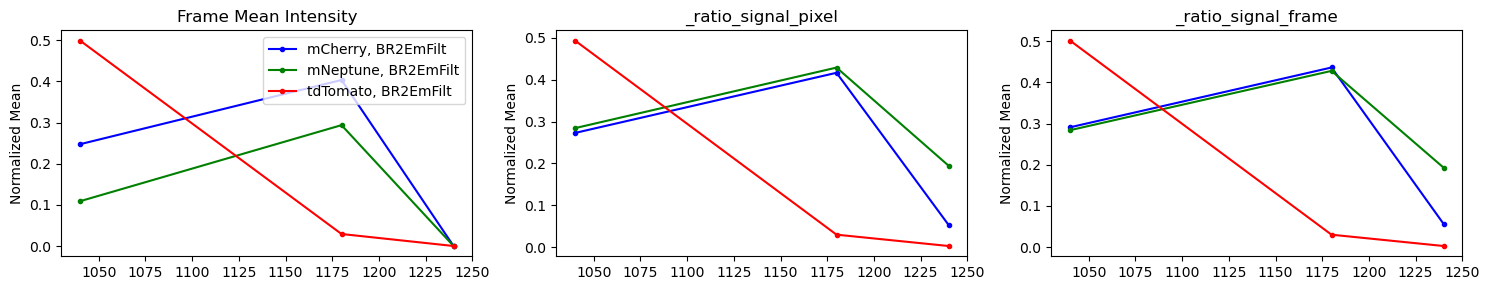

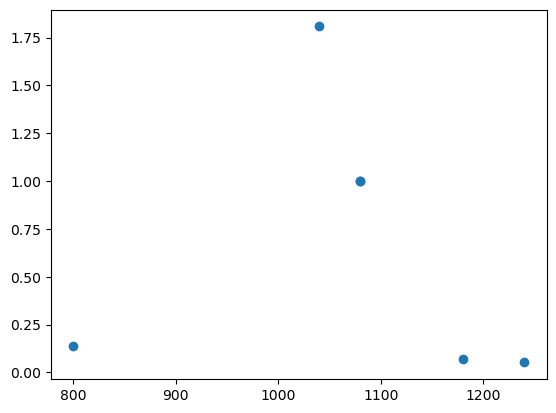

In [48]:
#then plot with wavelength on x axis and mean pixel value on y axis
# Sort the dataframe by numeric excitation wavelength
def plot_channel_curves(conditions_plus_fp_means, min_wavelength = 1050, max_wavelength = 1170):
    plot_df = conditions_plus_fp_means.sort_values(by='exc_wavelength')

    # Create subplots
    fig, axs = plt.subplots(1, 3, figsize=(15, 3))

    # Filter and sort
    print(conditions_plus_fp_means['exc_wavelength'] )
    print(min_wavelength)
    plot_df = conditions_plus_fp_means[
        (conditions_plus_fp_means['exc_wavelength'] >= min_wavelength) &
        (conditions_plus_fp_means['exc_wavelength'] <= max_wavelength)
    ].sort_values(by='exc_wavelength')



    # Plot 1: Frame mean
    marker_list = ['.', 'x', '+', 's']
    color_list = ['b', 'g', 'r']
    for i, this_filter in enumerate(plot_df['filter'].unique()):
        this_plot_df = plot_df[plot_df['filter'] == this_filter]
        fp_idx = 0
        for col in this_plot_df.columns:
            if col.endswith('_frame_mean'):
                fp = col.split('_')[0]
                fp_filter = f'{fp}, {this_filter}'
                #if i==0:
                axs[0].plot(this_plot_df['exc_wavelength'], this_plot_df[col], c=color_list[fp_idx], label=fp_filter, marker=marker_list[i])
                #else:
                #    axs[0].plot(this_plot_df['exc_wavelength'], this_plot_df[col], c=color_list[fp_idx], marker=marker_list[i])

                fp_idx+=1
    axs[0].set_title('Frame Mean Intensity')
    axs[0].set_ylabel('Normalized Mean')
    axs[0].legend()

    for i, this_filter in enumerate(plot_df['filter'].unique()):
        this_plot_df = plot_df[plot_df['filter'] == this_filter]
        fp_idx = 0
        for col in this_plot_df.columns:
            if col.endswith('_ratio_signal_pixel'):
                fp = col.split('_')[0]
                #fp_filter = f'{fp}, {this_filter}'
                if i==0:
                    axs[1].plot(this_plot_df['exc_wavelength'], this_plot_df[col], c=color_list[fp_idx], label=fp, marker=marker_list[i])
                else:
                    axs[1].plot(this_plot_df['exc_wavelength'], this_plot_df[col], c=color_list[fp_idx], marker=marker_list[i])

                fp_idx+=1
    axs[1].set_title('_ratio_signal_pixel')
    axs[1].set_ylabel('Normalized Mean')
    #axs[1].legend()
    
    for i, this_filter in enumerate(plot_df['filter'].unique()):
        this_plot_df = plot_df[plot_df['filter'] == this_filter]
        fp_idx = 0
        for col in this_plot_df.columns:
            if col.endswith('_ratio_signal_frame'):
                fp = col.split('_')[0]
                #fp_filter = f'{fp}, {this_filter}'
                if i==0:
                    axs[2].plot(this_plot_df['exc_wavelength'], this_plot_df[col], c=color_list[fp_idx], label=fp, marker=marker_list[i])
                else:
                    axs[2].plot(this_plot_df['exc_wavelength'], this_plot_df[col], c=color_list[fp_idx], marker=marker_list[i])

                fp_idx+=1
    axs[2].set_title('_ratio_signal_frame')
    axs[2].set_ylabel('Normalized Mean')
    #axs[2].legend()
    
    
    #exc_wavelength = plot_df['exc_wavelength']
        
    # Plot 2: Signal pixel ratio
    #for col in plot_df.columns:
    #    if col.endswith('_ratio_signal_pixel'):
    #        fp = col.split('_')[0]
    #        axs[1].plot(exc_wavelength, plot_df[col], label=fp, marker='.')
    #axs[1].set_title('Signal Pixel Ratio')
    #axs[1].set_ylabel('Normalized Signal')
    #axs[1].legend()

    # Plot 3: Signal frame ratio
    #for col in plot_df.columns:
    #    if col.endswith('_ratio_signal_frame'):
    #        fp = col.split('_')[0]
    #        axs[2].plot(exc_wavelength, plot_df[col], label=fp, marker='.')
    #axs[2].set_title('Signal Frame Ratio')
    #axs[2].set_ylabel('Normalized Frame Signal')
    #axs[2].set_xlabel('Excitation Wavelength (nm)')
    #axs[2].legend()

    plt.tight_layout()
    plt.show()
    figname = 'channel_intensity_curves.png'
    figpath = os.path.join(data_dir, figname)
    fig.savefig(figpath)
    
    
wavelength_only_df = conditions_plus_fp_means[conditions_plus_fp_means["filter"] == "BR2EmFilt"]
wavelength_only_df = conditions_plus_fp_means[conditions_plus_fp_means["exc_wavelength"].isin([1040, 1180, 1240])]

plot_channel_curves(wavelength_only_df, min_wavelength = 1000, max_wavelength = 1240)

ratio = conditions_plus_fp_means['tdTomato_ratio_signal_pixel']/conditions_plus_fp_means['mCherry_ratio_signal_pixel']

plt.scatter(conditions_plus_fp_means['exc_wavelength'], ratio)

In [42]:
#Define all the functions here
        
def produce_image_multicolor_stack(df, selected_channels=None, verbose=True):
    if not(selected_channels):
        selected_channels = conditions_plus_fp_means.index.to_list()

    image_columns = [col for col in conditions_plus_fp_means.columns if 'image_data' in col]

    # Storage for overlay
    multichannel_concat_image = []
    channel_names = []
    # Loop over each wavelength
    for i, idx in enumerate(selected_channels):
        row = conditions_plus_fp_means.loc[idx]

        images = []
        for col in image_columns:
            img = row[col]
            images.append(img)

        concat_image = np.concatenate(images, axis=1)
        multichannel_concat_image.append(concat_image)
        channel_names.append(idx)

    multichannel_concat_image = np.array(multichannel_concat_image)
    arr_stacked = np.transpose(multichannel_concat_image, (1, 2, 0))  # (1024, 3072, 3)
    image = np.expand_dims(arr_stacked, axis=0)
    if verbose:
        print(f"The image is {image.shape[3]} channels,{image.shape[1]}x{image.shape[2]} pixels and {image.shape[0]} Z frames")
    return image, channel_names



def plot_3_channels(image_multicolor_stack, color_channel_labels, bound=None):
    # Prepare figure: 3 for wavelengths, 1 for RGB overlay
    num_plots = len(color_channel_labels)+1
    fig, axs = plt.subplots(num_plots, 1, figsize=(12, 4*num_plots))

    for i in range(len(color_channel_labels)):
        axs[i].imshow(image_multicolor_stack[0,:,:,i], cmap='gray')
        axs[i].set_title(color_channel_labels[i])
        axs[i].axis('off')

    # Create RGB overlay (stack into channels)
    # Use first 3 items from concat_images
    selected_labels = color_channel_labels[0:3]
    #print(selected_labels)

    if len(selected_labels) == 3:
        rgb_overlay_2 = image_multicolor_stack[0,:,:,0:3]
        rgb_overlay_2 = rgb_overlay_2/np.max(rgb_overlay_2)
        axs[-1].imshow(rgb_overlay_2)
        channel_colors = ['R', 'G', 'B']
        channel_descriptions = [f"{color}: {label}" for color, label in zip(channel_colors, selected_labels)]
        axs[-1].set_title(f"RGB Overlay — " + ', '.join(channel_descriptions))
    else:
        axs[-1].text(0.5, 0.5, 'Insufficient data for RGB overlay', ha='center', va='center')
    axs[-1].axis('off')

    plt.tight_layout()
    plt.show()
    
    figname = 'all_channel_image_plus_rgb.png'
    figpath = os.path.join(data_dir, figname)
    fig.savefig(figpath)

    
#try to unmix using the emission only coefs (maybe 4) - use the unmixing app and save coefficients as a file in this folder

def make_unmixing_df(conditions_plus_fp_means, target_wavelengths=None, verbose=True):
    column_suffix = "_ratio_signal_frame"    # Column suffix to identify relevant data

    # Filter the dataframe for just the target wavelengths
    if target_wavelengths:
        filtered_df = conditions_plus_fp_means[conditions_plus_fp_means['exc_wavelength'].isin(target_wavelengths)]
    else:
        filtered_df = conditions_plus_fp_means
        
    # Make sure the data is sorted in wavelength order (just in case)
    filtered_df = filtered_df.sort_values(by='exc_wavelength')

    # Get the list of fluorophores by checking column names that end with the suffix
    fluorophores = [col.replace(column_suffix, '') for col in conditions_plus_fp_means.columns if col.endswith(column_suffix)]

    filtered_df['exc_wavelength_str'] = filtered_df['exc_wavelength'].astype(int).astype(str) + 'nm'

    channel_names = filtered_df[['filter', 'exc_wavelength_str']].astype(str).agg('_'.join, axis=1)
    # Build the 3x3 matrix
    unmixing_df = pd.DataFrame(index=channel_names, columns=fluorophores)

    for fp in fluorophores:
        colname = f"{fp}{column_suffix}"
        unmixing_df[fp] = filtered_df[colname].values

    #now sort the rows by their usefulness
    # Convert to numpy array
    matrix = unmixing_df.values

    # Perform QR decomposition with row pivoting on the transpose (to get row importance)
    Q, R, pivot_indices = qr(matrix.T, pivoting=True)

    # Rearranged index order from most to least independent
    sorted_row_names = unmixing_df.index[pivot_indices]

    # Reorder DataFrame
    sorted_unmixing_df = unmixing_df.loc[sorted_row_names]
        
    # Save as CSV
    save_path = os.path.join(data_dir, "unmixing_matrix.csv")
    sorted_unmixing_df.to_csv(save_path, index_label="wavelength")

    

    # Optional: preview the matrix
    if verbose:
        print(sorted_unmixing_df)
        #print(np.array(unmixing_df))
    #this should come out with the following organization:
    #[[Fp1_ch1, fp2_ch1, fp3_ch1],
    #[Fp1_ch2, fp2_ch2, fp3_ch2],
    #[Fp1_ch3, fp2_ch3, fp3_ch3]]
    
    return sorted_unmixing_df

def plot_scatters(overlay_stack, labels, unmixing_df, bound=0.06, elev=10, azim=-45):
    
    if not(bound):
        bound = np.max(overlay_stack)/4
    print(f'azis bound is {bound}')
    print(overlay_stack.shape)
    if isinstance(overlay_stack, np.ndarray):
        if len(overlay_stack.shape) == 4:
            overlay_stack = [overlay_stack[:, :, :, i] for i in range(len(labels))]
        elif len(overlay_stack.shape) == 3:  
            overlay_stack = [overlay_stack[:, :, i] for i in range(len(labels))]

    flattened = [img.flatten() for img in overlay_stack]
    
        
    sample_size = 30000
    if len(flattened[0]) > sample_size:
        indices = np.random.choice(len(flattened[0]), sample_size, replace=False)
        flattened = [arr[indices] for arr in flattened]

    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    combs = list(combinations(range(3), 2))
    
    selected_channels = unmixing_df.index[:3].tolist()   #get the first 3 channel names from the sorted unmixing df
    selected_indicies = [labels.index(idx) for idx in selected_channels]
    selected_flattened = [flattened[i] for i in selected_indicies]
    selected_labels =  [labels[i] for i in selected_indicies]

    for ax, (i, j) in zip(axs, combs):
        x = selected_flattened[i]
        y = selected_flattened[j]
        ax.scatter(x, y, alpha=.3, s=1)
        ax.set_title(f'{selected_labels[i]} vs {selected_labels[j]}')
        ax.set_xlabel(f'{selected_labels[i]}')
        ax.set_ylabel(f'{selected_labels[j]}')
        ax.set_xlim(0, bound)
        ax.set_ylim(0, bound)
        # Plot arrows for each FP
        for fp in unmixing_df.columns:
            arrow_start = (0, 0)
            vec_x = unmixing_df.loc[selected_labels[i], fp]
            vec_y = unmixing_df.loc[selected_labels[j], fp]
            magnitude = np.sqrt(vec_x**2 + vec_y**2)

            scale = (bound / 2) / magnitude
            arrow_end = (vec_x * scale, vec_y * scale)
            ax.arrow(*arrow_start, *(np.array(arrow_end)-np.array(arrow_start)), 
                     color='red', head_width=0.002, length_includes_head=True)
            ax.text(arrow_end[0] + 0.001, arrow_end[1] + 0.001, fp, color='red', fontsize=9)
            
    plt.tight_layout()
    plt.show()
    
    figname = '2d_scatter.png'
    figpath = os.path.join(data_dir, figname)
    fig.savefig(figpath)
    
    # Prepare figure
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot pixel data
    ax.scatter(selected_flattened[0], selected_flattened[1], selected_flattened[2], s=1, alpha=0.3)

    # Axis labels from wavelengths
    ax.set_xlabel(f'{selected_labels[0]}')
    ax.set_ylabel(f'{selected_labels[1]}')
    ax.set_zlabel(f'{selected_labels[2]}')

    # Set axis bounds
    ax.set_xlim(0, bound)
    ax.set_ylim(0, bound)
    ax.set_zlim(0, bound)

    # Add arrows for each fluorophore
    for fp in unmixing_df.columns:
        x, y, z = [unmixing_df.loc[wl, fp] for wl in selected_labels]
        norm = np.sqrt(x**2 + y**2 + z**2)
        if norm > 0:
            scale = (bound / 1) / norm
            x_scaled, y_scaled, z_scaled = x * scale, y * scale, z * scale
            ax.quiver(0, 0, 0, x_scaled, y_scaled, z_scaled, color='red', arrow_length_ratio=0.1)
            ax.text(x_scaled + 0.002, y_scaled + 0.002, z_scaled + 0.002, fp, color='red', fontsize=10)

    ax.view_init(elev=elev, azim=azim)
    ax.set_title('3D Pixel Intensity Scatter with Fluorophore Vectors')
    plt.tight_layout()
    plt.show()
    
    figname = '3d_scatter.png'
    figpath = os.path.join(data_dir, figname)
    fig.savefig(figpath)
    
    
    data = np.array([selected_flattened[0], selected_flattened[1], selected_flattened[2]]).T
    print(data.shape)
    

    tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
    tsne_results = tsne.fit_transform(data)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(tsne_results[:, 0], tsne_results[:, 1])
    plt.title('t-SNE Plot of High-Dimensional Data')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.grid(True)
    plt.show()
        


In [43]:
#sub_df = conditions_plus_fp_means[conditions_plus_fp_means["exc_wavelength"] == 1080]
wavelength_list = [800, 1040, 1080, 1120, 1200, 1180, 1240]
sub_df = conditions_plus_fp_means[conditions_plus_fp_means["exc_wavelength"].isin(wavelength_list)]

#   OrangeEmFilt   RedEmFilt    FarRedEmFilt    BR2EmFilt
orange_df = sub_df[sub_df["filter"] == "BR2EmFilt"]
orange_df = orange_df[orange_df["exc_wavelength"] == 1040]

red_df = sub_df[sub_df["filter"] == "BR2EmFilt"]
red_df = red_df[red_df["exc_wavelength"] == 800]

#FarRedEmFilt
far_red_df = sub_df[sub_df["filter"] == "BR2EmFilt"]
far_red_df = far_red_df[far_red_df["exc_wavelength"] == 1200]

sub_df = pd.concat([orange_df, red_df, far_red_df], ignore_index=True)
#far_red_df.head(5)
sub_df.head()

,filter,exc_wavelength,power,mCherry_frame_mean,mNeptune_frame_mean,tdTomato_frame_mean,mCherry_signal_mask_mean,mCherry_ratio_signal_pixel,mCherry_ratio_signal_frame,mCherry_image_data,mNeptune_signal_mask_mean,mNeptune_ratio_signal_pixel,mNeptune_ratio_signal_frame,mNeptune_image_data,tdTomato_signal_mask_mean,tdTomato_ratio_signal_pixel,tdTomato_ratio_signal_frame,tdTomato_image_data
0,BR2EmFilt,1040.0,182poc,0.247520,0.108953,0.499369,428.025548,0.272721,0.290946,"[[-2.1313609467455628, -2.1313609467455628, -2...",559.890151,0.284205,0.283935,"[[-14.299961345187477, -14.299961345187477, -1...",665.328272,0.493181,0.501584,"[[-4.448090692124104, -4.448090692124104, -4.4..."
1,BR2EmFilt,800.0,128poc,0.416083,0.718393,0.079338,653.897251,0.442508,0.444480,"[[-13.766074950690335, -14.766074950690335, -1...",1494.150237,0.759786,0.757723,"[[-64.57750289911094, -64.57750289911094, -64....",69.354242,0.060729,0.052285,"[[-20.66467780429594, -20.66467780429594, -20...."


The image is 12 channels,512x1536 pixels and 1 Z frames
                   mCherry  mNeptune  tdTomato
BR2EmFilt_800nm   0.433034  0.573803  0.039186
BR2EmFilt_1040nm  0.281010  0.312835  0.536460
BR2EmFilt_1200nm  0.228341  0.424844  0.008781
azis bound is 500
(1, 512, 1536, 12)


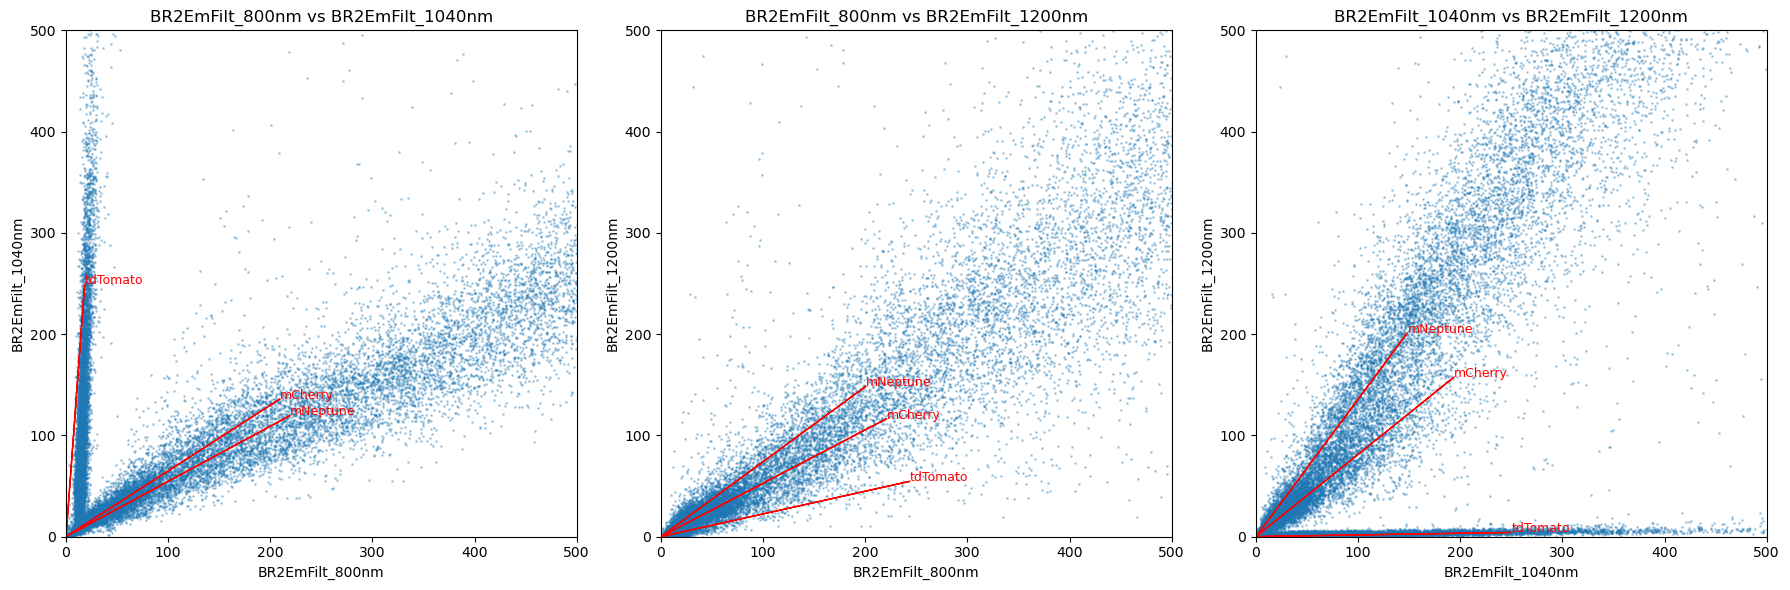

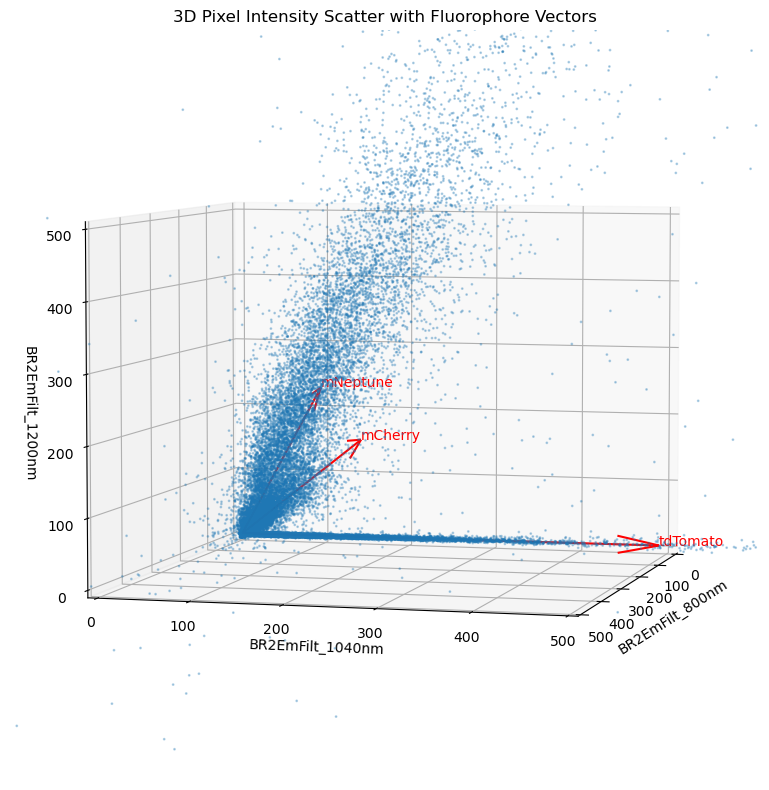

(30000, 3)


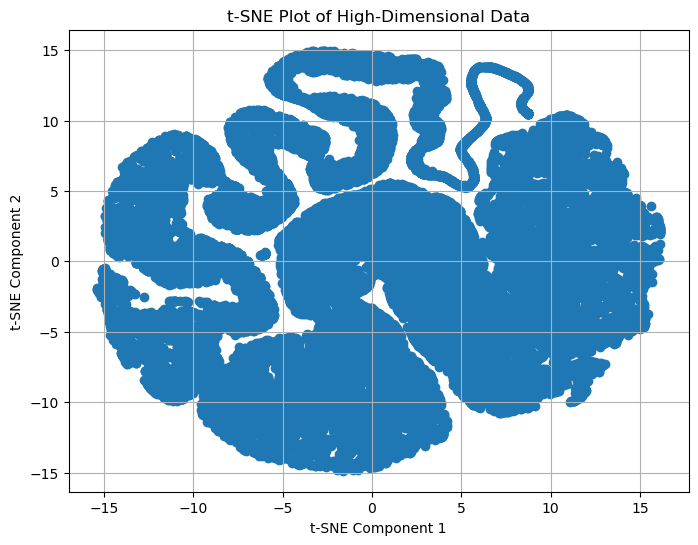

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


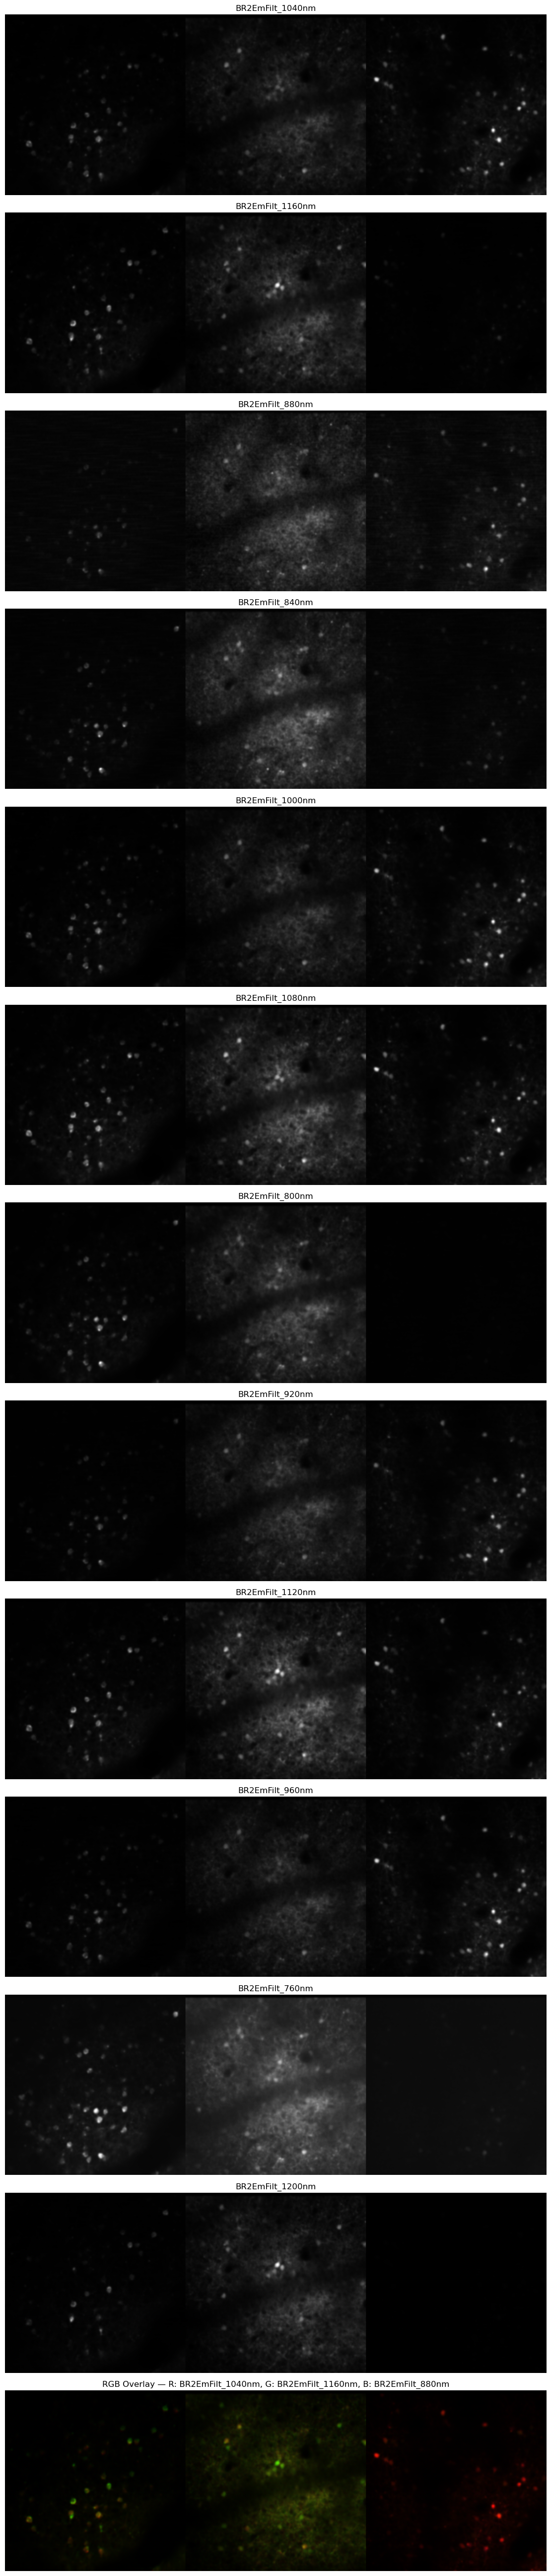

In [257]:
mixed_image, channel_names = produce_image_multicolor_stack(sub_df, verbose=True)
unmixing_df = make_unmixing_df(sub_df)
plot_scatters(mixed_image, channel_names, unmixing_df, elev=5, azim=15, bound=500)
plot_3_channels(mixed_image, channel_names)

In [ ]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
tsne_results = tsne.fit_transform(data)
    

In [215]:
def run_main_and_plots(df_in):
    mixed_image, channel_names = produce_image_multicolor_stack(df_in, verbose=True)
    
    unmixing_df = make_unmixing_df(df_in)
    selected_channels = unmixing_df.index[:3].tolist()   #get the first 3 channel names from the sorted unmixing df
    selected_indicies = [channel_names.index(idx) for idx in selected_channels]
    selected_images = mixed_image[:,:,:,selected_indicies]
    selected_labels =  [channel_names[i] for i in selected_indicies]
    selected_unmixing_df = unmixing_df.loc[selected_channels]
    plot_scatters(selected_images, selected_labels, selected_unmixing_df, bound=None)

    print(selected_images.shape)
    print(selected_labels)
    print(selected_unmixing_df)

    unmixed_image, residuals = comp.unmix(np.array(selected_unmixing_df), selected_images, nonnegative = True, verbose=False)

    plot_3_channels(unmixed_image, selected_labels)


In [31]:
#this is with the best of all of them
#run_main_and_plots(conditions_plus_fp_means)

In [32]:
#this is with the wavelengths
#wavelength_df = conditions_plus_fp_means[conditions_plus_fp_means["filter"] == "BR2EmFilt"]

#run_main_and_plots(wavelength_df)



In [14]:
filter_df.head()


,filter,exc_wavelength,power,pmt,mCherry_frame_mean,mNeptune_frame_mean,tdTomato_frame_mean,mCherry_signal_mask_mean,mCherry_ratio_signal_pixel,mCherry_ratio_signal_frame,mCherry_image_data,mNeptune_signal_mask_mean,mNeptune_ratio_signal_pixel,mNeptune_ratio_signal_frame,mNeptune_image_data,tdTomato_signal_mask_mean,tdTomato_ratio_signal_pixel,tdTomato_ratio_signal_frame,tdTomato_image_data
BR2EmFilt_1100nm,BR2EmFilt,1100.0,257poc,600pmt,0.196001,0.356876,0.362016,155.230745,0.294788,0.231125,"[[-124.6615595671573, -124.6615595671573, -124...",13.476609,0.275911,0.252284,"[[-101.6210343775697, -101.6210343775697, -100...",117.505666,0.419384,0.405643,"[[-29.988457914320357, -29.988457914320357, -2..."
BR2EmFilt_1000nm,BR2EmFilt,1000.0,100poc,600pmt,0.005626,0.037678,0.020198,4.624257,0.013392,0.006885,"[[-114.48828786091593, -114.48828786091593, -1...",1.712550,0.052735,0.032059,"[[-70.97162391575374, -70.97162391575374, -71....",10.687987,0.042965,0.036896,"[[-31.553039244377693, -30.553039244377693, -2..."
BR2EmFilt_820nm,BR2EmFilt,820.0,85poc,600pmt,0.000000,0.042802,0.000000,5.495316,0.016216,0.008182,"[[-101.15414572542181, -101.15414572542181, -1...",0.740578,0.018932,0.013864,"[[-8.519446802302454, -8.519446802302454, -9.5...",1.391562,0.010100,0.004804,"[[-26.408256659452192, -26.408256659452192, -2..."
BR2EmFilt_800nm,BR2EmFilt,800.0,85poc,600pmt,0.006763,0.087681,0.012688,14.869110,0.034913,0.022139,"[[-105.16367826555208, -105.16367826555208, -1...",4.495239,0.126696,0.084151,"[[-74.09054616833338, -74.09054616833338, -74....",2.743709,0.019785,0.009472,"[[-36.782501310504294, -36.782501310504294, -3..."
BR2EmFilt_1160nm,BR2EmFilt,1160.0,653poc,600pmt,1.000000,0.959323,0.297049,671.629992,1.000000,1.000000,"[[-118.09246307502949, -118.09246307502949, -1...",46.707097,0.797326,0.874362,"[[-86.3236756943155, -86.3236756943155, -86.32...",100.376175,0.371962,0.346510,"[[-32.03160325326661, -32.03160325326661, -33...."


                           filter  exc_wavelength   power     pmt  \
OrangeEmFilt_1140nm  OrangeEmFilt          1140.0  565poc  600pmt   
RedEmFilt_1140nm        RedEmFilt          1140.0  565poc  600pmt   
BR2EmFilt_1140nm        BR2EmFilt          1140.0  565poc  600pmt   
FarRedEmFilt_1140nm  FarRedEmFilt          1140.0  565poc  600pmt   

                     mCherry_frame_mean  mNeptune_frame_mean  \
OrangeEmFilt_1140nm            0.011746             0.034260   
RedEmFilt_1140nm               0.157220             0.177368   
BR2EmFilt_1140nm               0.533890             0.697771   
FarRedEmFilt_1140nm            0.115856             0.492229   

                     tdTomato_frame_mean  mCherry_signal_mask_mean  \
OrangeEmFilt_1140nm             0.247550                 11.291091   
RedEmFilt_1140nm                0.588806                196.154646   
BR2EmFilt_1140nm                1.000000                647.816486   
FarRedEmFilt_1140nm             0.253217             

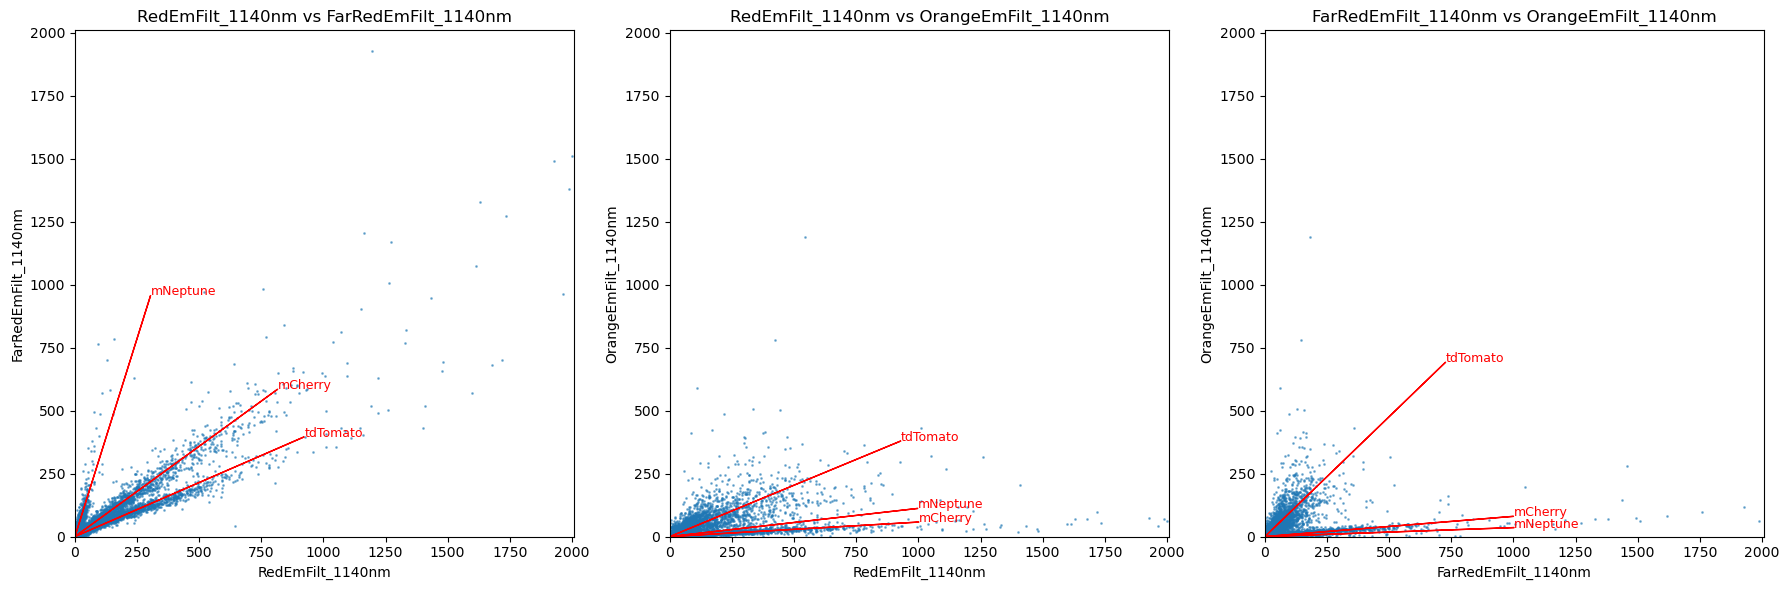

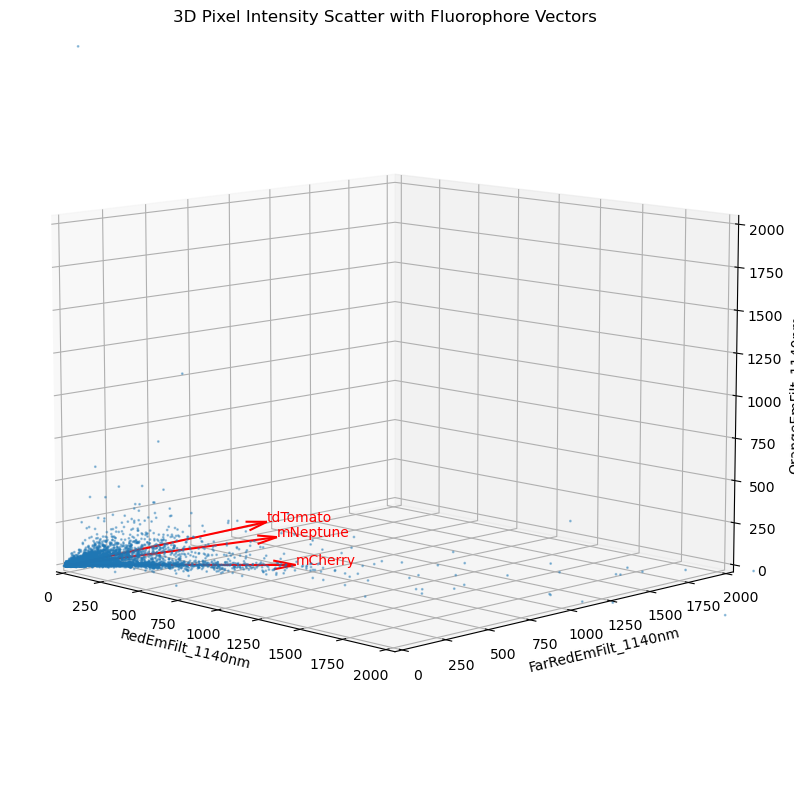

(1, 1024, 3072, 3)
['RedEmFilt_1140nm', 'FarRedEmFilt_1140nm', 'OrangeEmFilt_1140nm']
                      mCherry  mNeptune  tdTomato
RedEmFilt_1140nm     0.158005  0.141566  0.588377
FarRedEmFilt_1140nm  0.113251  0.444807  0.252355
OrangeEmFilt_1140nm  0.009095  0.015857  0.240192


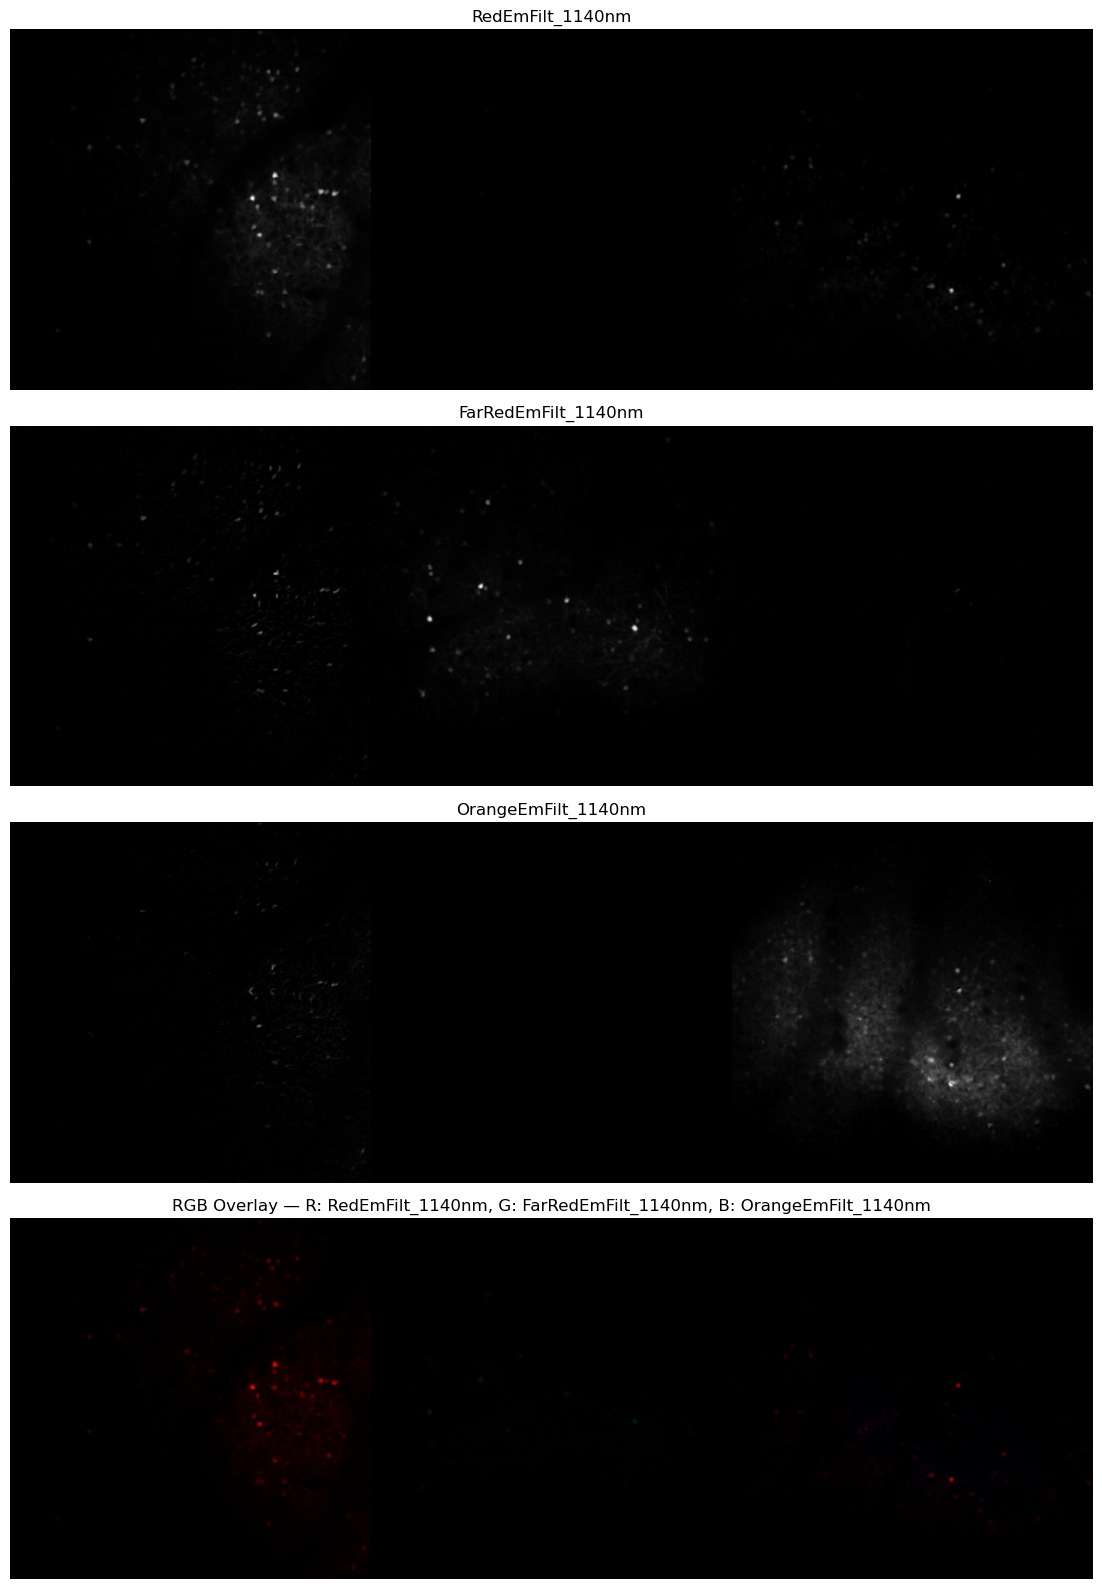

In [33]:
#this is with 4 filters at 1140
filter_df = conditions_plus_fp_means[conditions_plus_fp_means["exc_wavelength"] == 1140]
#print(filter_df.head(5))

#filter_df = filter_df[filter_df["filter"] != "BR2EmFilt"]
run_main_and_plots(filter_df)

In [20]:
print(conditions_plus_fp_means.index)

Index(['BR2EmFilt_1100nm', 'BR2EmFilt_1000nm', 'BR2EmFilt_820nm',
       'BR2EmFilt_800nm', 'BR2EmFilt_1160nm', 'BR2EmFilt_920nm',
       'BR2EmFilt_1140nm', 'BR2EmFilt_1040nm', 'BR2EmFilt_1120nm',
       'BR2EmFilt_1020nm', 'BR2EmFilt_1080nm', 'BR2EmFilt_1060nm'],
      dtype='object')


In [19]:
#indices_to_keep = ['FarRedEmFilt_1140nm', 'RedEmFilt_1140nm', 'BR2EmFilt_1160nm']  # index labels

indices_to_keep = ['OrangeEmFilt_1140nm', 'RedEmFilt_1080nm', 'BR2EmFilt_1140nm']  # index labels
filtered_df = conditions_plus_fp_means.loc[indices_to_keep]
run_main_and_plots(filtered_df)


KeyError: "['OrangeEmFilt_1140nm', 'RedEmFilt_1080nm'] not in index"

In [39]:
print(unmixing_df.head(5))

                      mCherry  mNeptune  tdTomato
BR2EmFilt_1160nm     1.000000  1.000000  0.663688
BR2EmFilt_1120nm     0.268830  0.325743  0.875411
FarRedEmFilt_1140nm  0.113251  0.444807  0.252355
FarRedEmFilt_800nm   0.003418  0.006400  0.003395
BR2EmFilt_820nm      0.004312  0.020146  0.004804


In [142]:
dirpath = r"\\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_20250521\exp93.animal3\FOV1"
def plot_and_classify(dirpath):
    pair_1_keywords = ['FarRedEmFilt_1140nm', 'RedEmFilt_1140nm']
    pair_2_keywords = ['RedEmFilt_1080nm', 'OrangeEmFilt_1140nm']
    pair_3_keywords = ['BR2EmFilt_1140nm', 'OrangeEmFilt_1140nm']

    pair_keywords = [pair_1_keywords, pair_2_keywords, pair_3_keywords]

    num_scatters = len(pair_keywords)


    signal_mask_all = None
    tiff_path_pairs = []
    for i, (keyword_1, keyword_2) in enumerate(pair_keywords):
        tiff_1_path = None
        tiff_2_path = None
        try:
            tiff_1_path = os.path.join(dirpath, keyword_1+'*', '*Ch1*.ome*')#[0]

            #print(r"\\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_20250521\exp93.animal3\FOV1\FarRedEmFilt_1140nm_565poc_600pm-144\FarRedEmFilt_1140nm_565poc_600pm-144_Cycle00001_Ch1_000001.ome.tif")
            tiff_1_path = glob(tiff_1_path)[0]
            #print(tiff_1_path
            tiff_2_path = os.path.join(dirpath, keyword_2+'*', '*Ch1*.ome*')
            #print(tiff_2_path)
            #print(r"\\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_20250521\exp93.animal3\FOV1\RedEmFilt_1140nm_565poc_600pm-144\RedEmFilt_1140nm_565poc_600pm-144_Cycle00001_Ch1_000001.ome.tif")
            tiff_2_path = glob(tiff_2_path)[0]

        except IndexError as E:
            pass
            #raise(E)
        tiff_path_pairs.append([tiff_1_path, tiff_2_path])
    
    tiff_2_found = False
    for i, (tiff_1_path, tiff_2_path) in enumerate(tiff_path_pairs):
        if tiff_1_path and tiff_2_path:
            
            if not(tiff_2_found):
                tiff_2_found = True
                print(dirpath)
                
                #only make the plot if there is a working pair
                fig, axs = plt.subplots(3, num_scatters, figsize=(4*num_scatters, 12))
                plt.suptitle(dirpath)

                
            tiff_1, reference_tags = io.imread(tiff_1_path)
            tiff_2, reference_tags = io.imread(tiff_2_path)

            # Apply Gaussian smoothing in X and Y (in pixel units)
            # If image is 2D: sigma = (y, x)
            # If image is 3D (e.g. Z, Y, X): use sigma = (z, y, x)
            tiff_1 = gaussian_filter(tiff_1, sigma=smoothing_std)
            tiff_2 = gaussian_filter(tiff_2, sigma=smoothing_std)


            # generate pixel mask for the noise
            noise_mask = tiff_1 < np.percentile(tiff_1, 30)
            # generate pixel mask for the signal
            signal_mask = tiff_1 > np.percentile(tiff_1, 30)
            tiff_1 = tiff_1 - np.mean(tiff_1[noise_mask])

            # generate pixel mask for the noise
            noise_mask = tiff_2 < np.percentile(tiff_2, 30)
            # generate pixel mask for the signal
            signal_mask = tiff_2 > np.percentile(tiff_2, 30)
            tiff_2 = tiff_2 - np.mean(tiff_2[noise_mask])

            # motion correct using rigid translation
            shift_estimate, _, _ = phase_cross_correlation(tiff_1, tiff_2, upsample_factor=10)

            max_shift = max_shift_fraction * np.array(tiff_2.shape)
            if np.any(np.abs(shift_estimate) > max_shift):
                print(f"Warning: Estimated shift exceeds max shift fraction of {max_shift_fraction} for {index}, shift set to 0.")
                tiff_2 = image
            else:
                tiff_2 = shift(tiff_2, shift=shift_estimate, mode='nearest')

            axs[0,i].scatter(tiff_1, tiff_2, alpha=.3)
            axs[0,i].set_xlabel(pair_keywords[i][0])
            axs[0,i].set_ylabel(pair_keywords[i][1])


            bound = np.max([np.max(tiff_2), np.max(tiff_2)])
            for fp in unmixing_df.columns:
                arrow_start = (0, 0)
                vec_x = unmixing_df.loc[pair_keywords[i][0], fp]
                vec_y = unmixing_df.loc[pair_keywords[i][1], fp]
                #magnitude = np.sqrt(vec_x**2 + vec_y**2)#

                #scale = (bound / 2) / magnitude
                #arrow_end = (vec_x * scale, vec_y * scale)
                #axs[0,i].arrow(*arrow_start, *(np.array(arrow_end)-np.array(arrow_start)), 
                #         color='red', head_width=0.002, length_includes_head=True)
                #axs[0,i].text(arrow_end[0] + 0.001, arrow_end[1] + 0.001, fp, color='red', fontsize=9)
                if 'mneptune' in fp.lower():
                    mNeptune_vec = [vec_x, vec_y]
                if 'tdtomato' in fp.lower():
                    tdTomato_vec = [vec_x, vec_y]

            # Average the two fluorophore vectors to get a mid-point direction
            decision_vect_arrow_end = 0.5 * (np.array(mNeptune_vec) + np.array(tdTomato_vec))

            # Normalize and scale to half the plot bound
            magnitude = np.linalg.norm(decision_vect_arrow_end)
            scale = (bound) / magnitude
            arrow_end = decision_vect_arrow_end * scale

            #arrow_end = (decision_vect_arrow_end[0] * scale, decision_vect_arrow_end[1]* scale)
            axs[0,i].arrow(*arrow_start, *(np.array(arrow_end)-np.array(arrow_start)), 
                         color='black', head_width=0.002, length_includes_head=True)

            if signal_mask_all is None:
                lowest_signal_pixel = np.percentile(tiff_1, 95)
                signal_mask_all = tiff_1 > lowest_signal_pixel

            x = tiff_1[signal_mask_all]
            y = tiff_2[signal_mask_all]
            # Flatten if necessary
            if x.ndim > 1:
                x_flat = x.flatten()
                y_flat = y.flatten()
            else:
                x_flat = x
                y_flat = y

            boundry_ratio = arrow_end[0]/arrow_end[1]

            tiff_ratio = np.divide(x_flat, y_flat)
            labels = np.where(tiff_ratio < boundry_ratio, 'mNeptune', 'tdTomato')
            colors = np.where(labels == 'mNeptune', 'blue', 'yellow')

            # Plot (only works with 1D)
            if x_flat.ndim == 1:
                axs[0, i].scatter(x_flat, y_flat, c=colors, alpha=0.5, s=1)

            # Count
            print(f"mNeptune: {(labels == 'mNeptune').sum()} points")
            print(f"tdTomato: {(labels == 'tdTomato').sum()} points")

            for fp in unmixing_df.columns:
                arrow_start = (0, 0)
                vec_x = unmixing_df.loc[pair_keywords[i][0], fp]
                vec_y = unmixing_df.loc[pair_keywords[i][1], fp]
                magnitude = np.sqrt(vec_x**2 + vec_y**2)

                scale = (bound / 2) / magnitude
                arrow_end = (vec_x * scale, vec_y * scale)
                axs[0,i].arrow(*arrow_start, *(np.array(arrow_end)-np.array(arrow_start)), 
                         color='red', head_width=0.002, length_includes_head=True)
                axs[0,i].text(arrow_end[0] + 0.001, arrow_end[1] + 0.001, fp, color='red', fontsize=14)

            #Now plot the RGB image of the classification
            try:
                tiff_ratio = np.divide(tiff_1, tiff_2)
                labels = np.where(tiff_ratio < boundry_ratio, 'mNeptune', 'tdTomato')
                rgb_image = np.zeros((*labels.shape, 3), dtype=np.float32)

                # Assign red to mNeptune (e.g., [1, 0, 0]) and blue to tdTomato (e.g., [0, 0, 1])
                rgb_image[labels == 'mNeptune'] = [1, 0, 0]  # Red
                rgb_image[labels == 'tdTomato'] = [0, 0, 1]  # Blue
                rgb_image_masked = rgb_image * signal_mask_all[:, :, np.newaxis]

                # Plot
                axs[1,i].imshow(rgb_image_masked)
                axs[1,i].set_title('Pixel Classification: mNeptune (Red) vs tdTomato (Blue)')
                axs[1,i].axis('off')
            except Exception as E:
                pass # expected to fail fo Z stacks right now

            
            #Now plot the RGB image of the original
            try:
                # Normalize images for visualization
                tiff_1_norm = tiff_1 / np.max(tiff_1)
                tiff_2_norm = tiff_2 / np.max(tiff_2)

                # Stack into RGB (Red: tiff_1, Blue: tiff_2, Green: 0)
                rgb_image = np.stack([tiff_1_norm, np.zeros_like(tiff_1), tiff_2_norm], axis=-1)

                # Plot
                axs[2,i].imshow(rgb_image)
            except Exception as E:
                pass # expected to fail fo Z stacks right now

    if tiff_2_found:
        plt.suptitle(dirpath)
        plt.tight_layout()
        plt.show()

        figname = '2d_scatter.png'
        figpath = os.path.join(dirpath, figname)
        fig.savefig(figpath)

\\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_20250521\exp93.animal3\FOV1


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mNeptune: 10963 points
tdTomato: 2062 points


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mNeptune: 12730 points
tdTomato: 295 points


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mNeptune: 10814 points
tdTomato: 2211 points


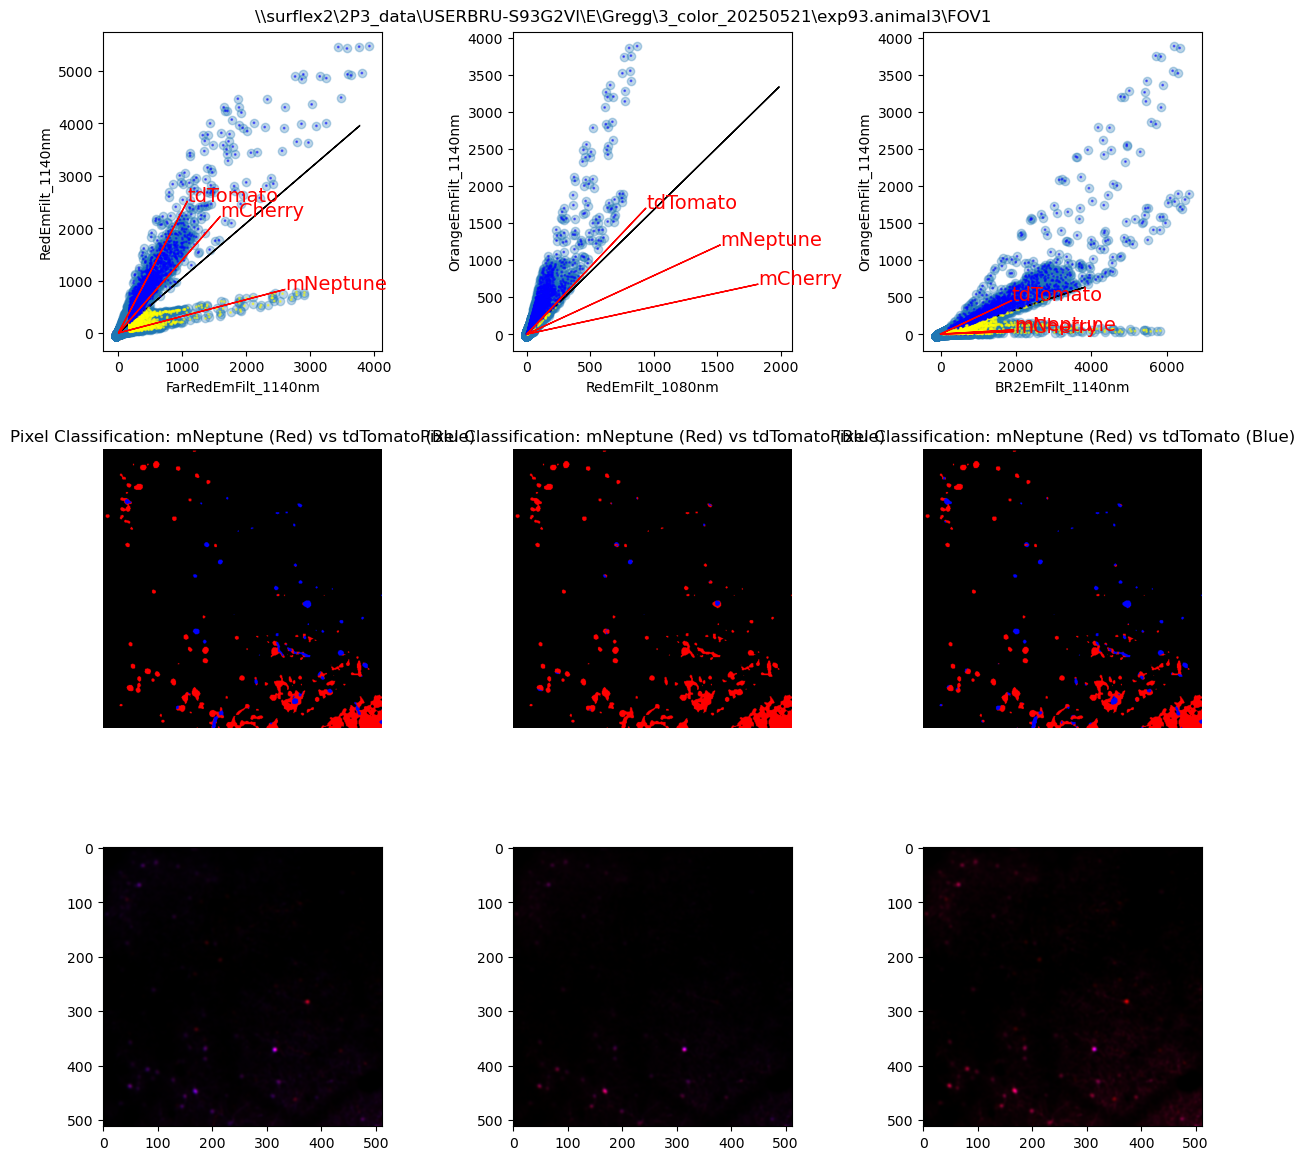

In [143]:
plot_and_classify(dirpath)

\\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_20250521\exp93.animal3\FOV1


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mNeptune: 10963 points
tdTomato: 2062 points


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mNeptune: 12730 points
tdTomato: 295 points


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mNeptune: 10814 points
tdTomato: 2211 points


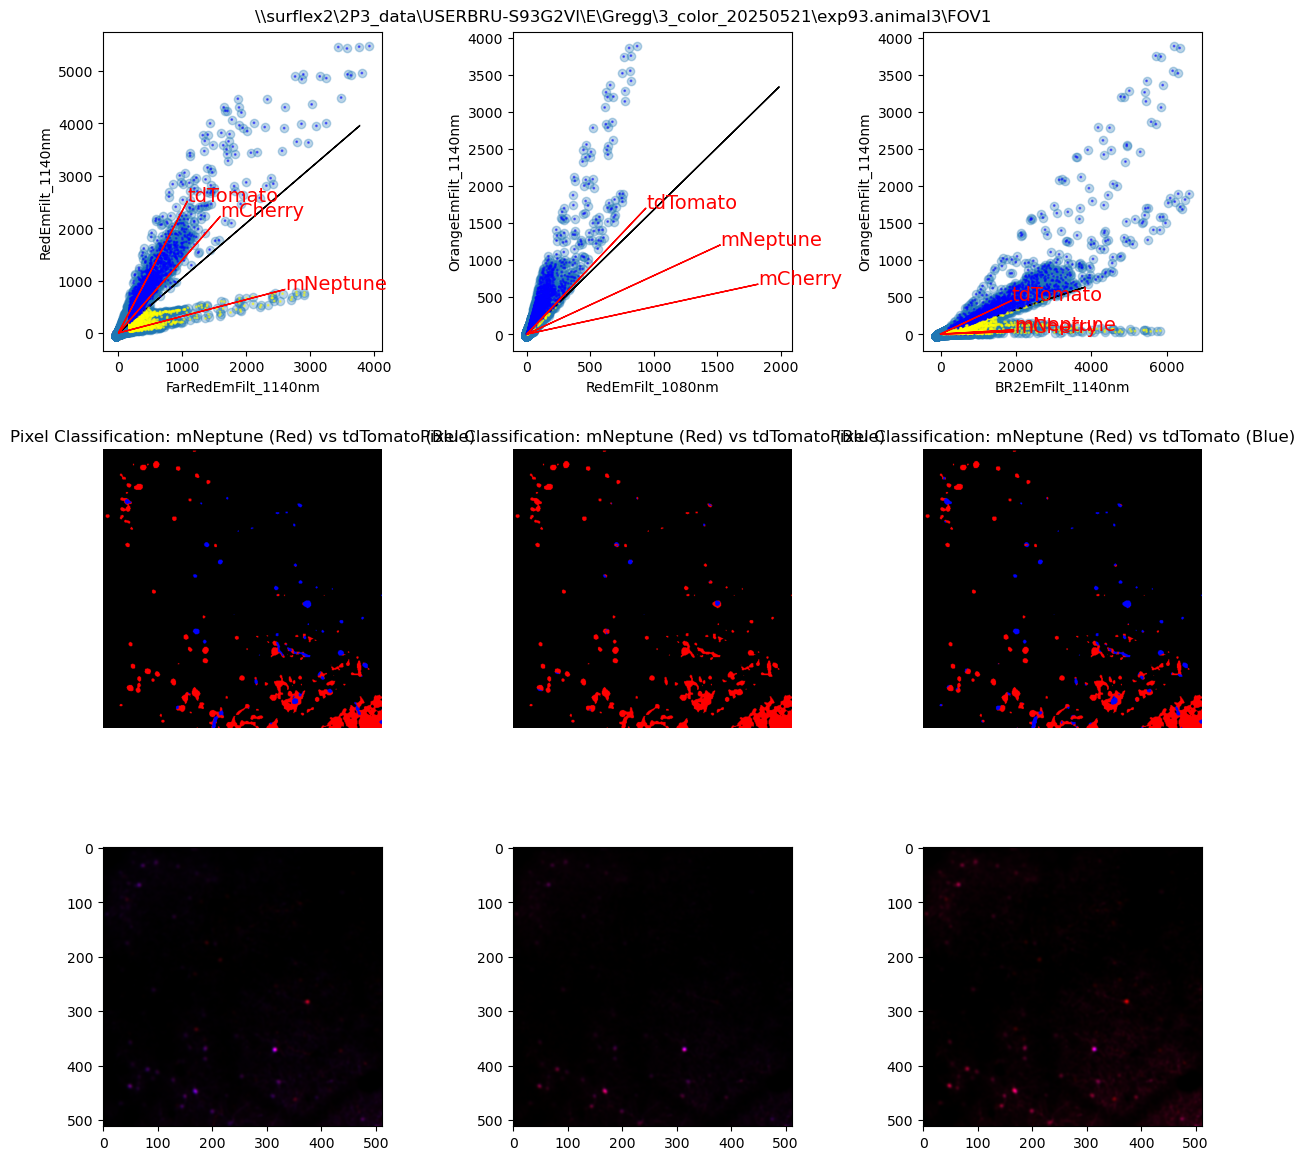

\\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_20250521\exp93.animal3\FOV2


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mNeptune: 8922 points
tdTomato: 4174 points
mNeptune: 10672 points
tdTomato: 2424 points


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mNeptune: 1301 points
tdTomato: 11795 points


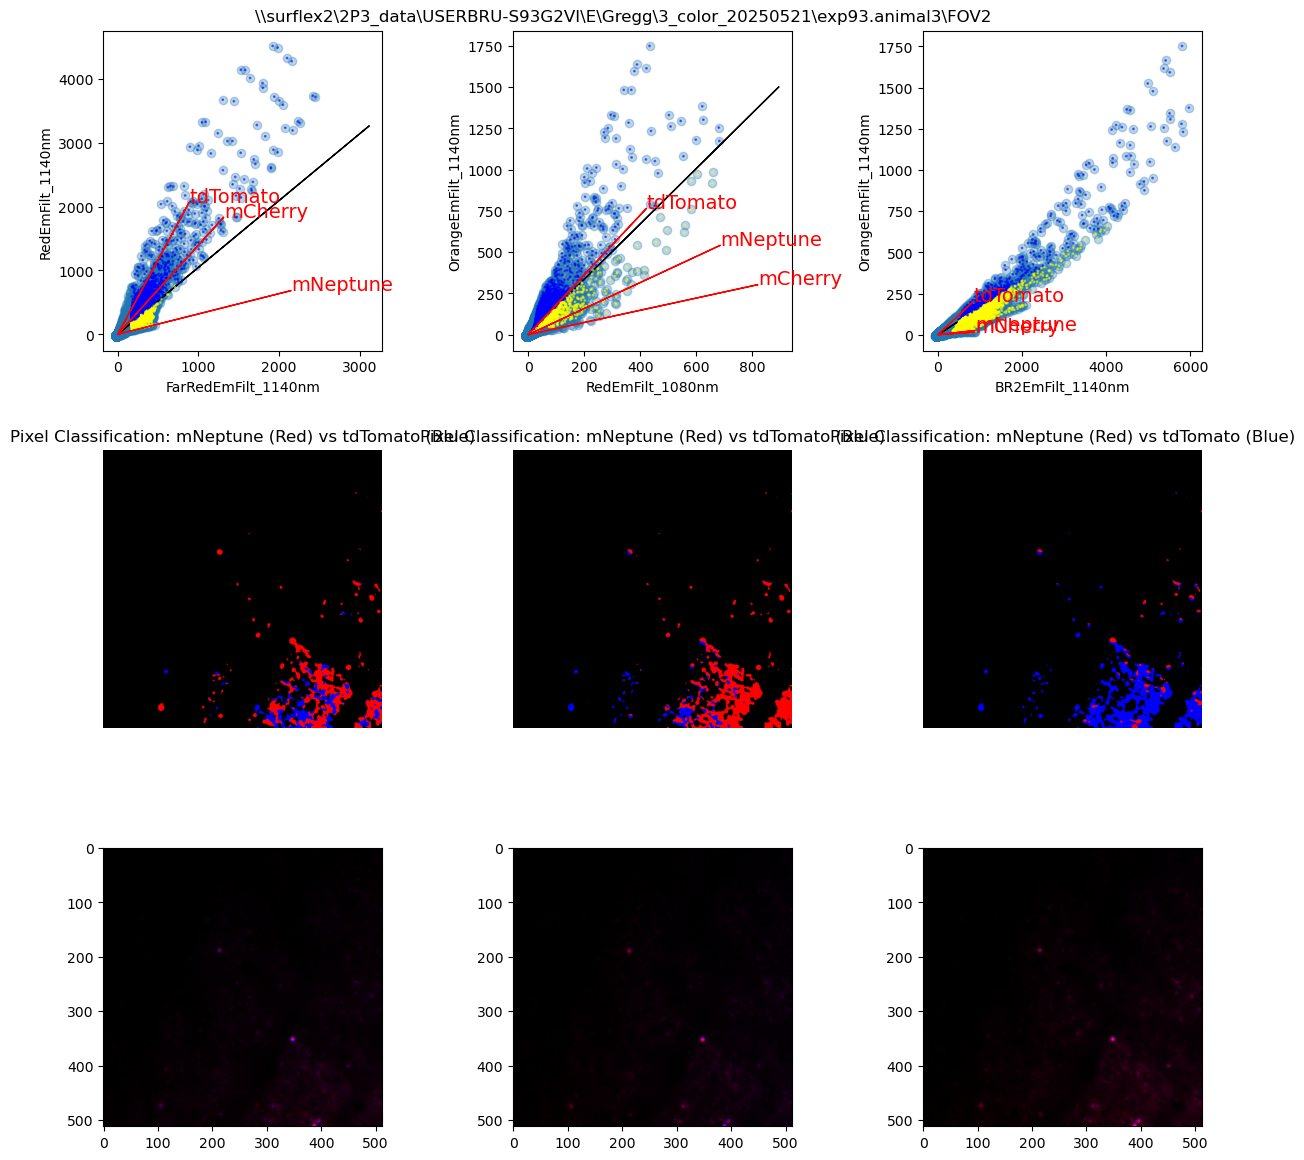

\\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_20250522\exp93.animal1\FOV1-z-stack_50-300um
mNeptune: 340173 points
tdTomato: 23 points
mNeptune: 53 points
tdTomato: 340143 points
Error processing \\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_20250522\exp93.animal1\FOV1-z-stack_50-300um: images must be same shape
\\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_20250522\exp93.animal1\FOV2
mNeptune: 331152 points
tdTomato: 1767 points
mNeptune: 0 points
tdTomato: 332919 points
mNeptune: 330907 points
tdTomato: 2012 points


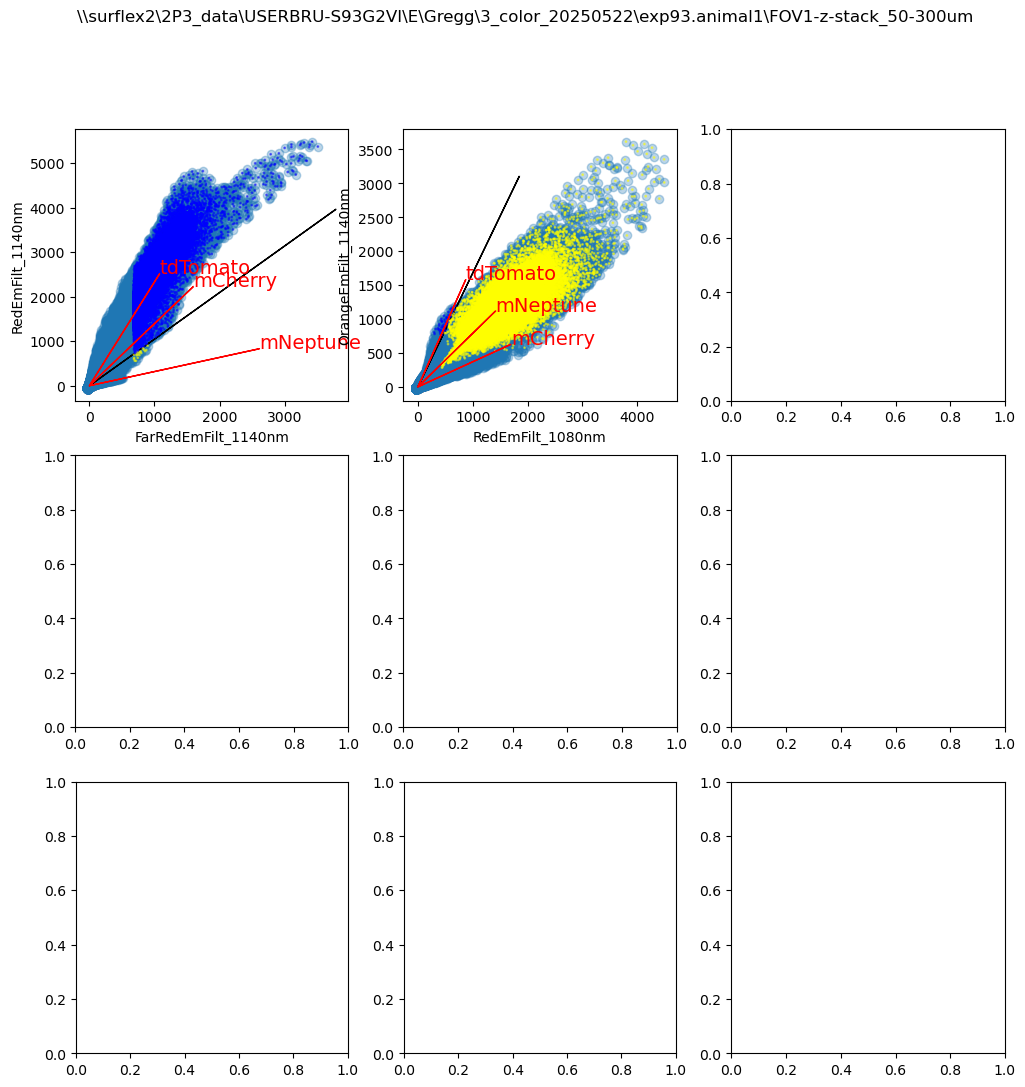

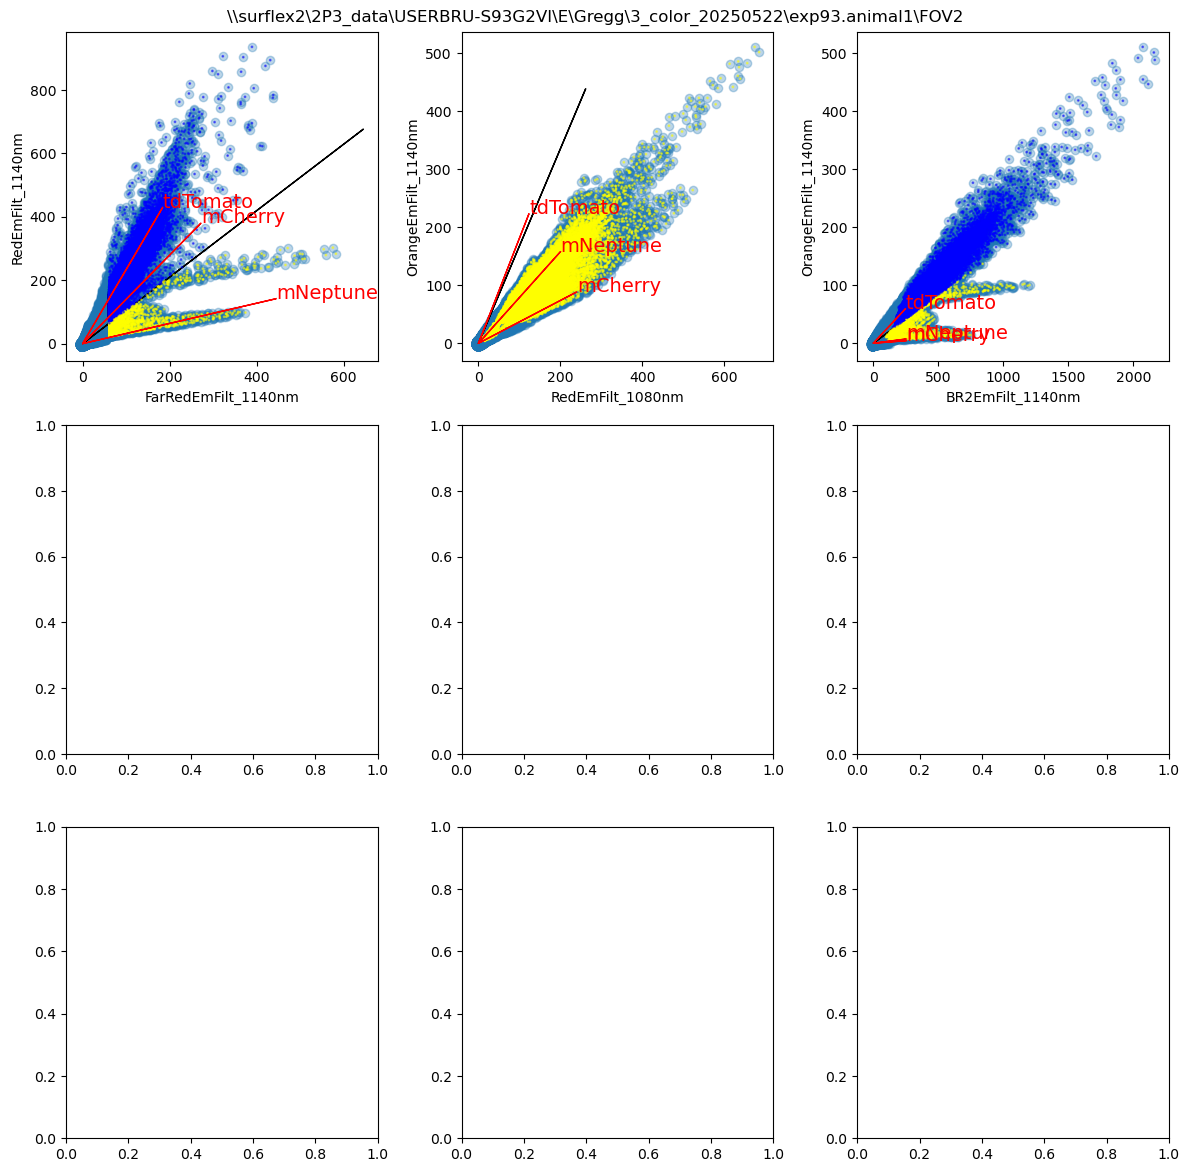

\\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_control_mice_20250514\mCherry_mouse


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mNeptune: 49970 points
tdTomato: 2333 points


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mNeptune: 1 points
tdTomato: 52302 points


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mNeptune: 1229 points
tdTomato: 51074 points


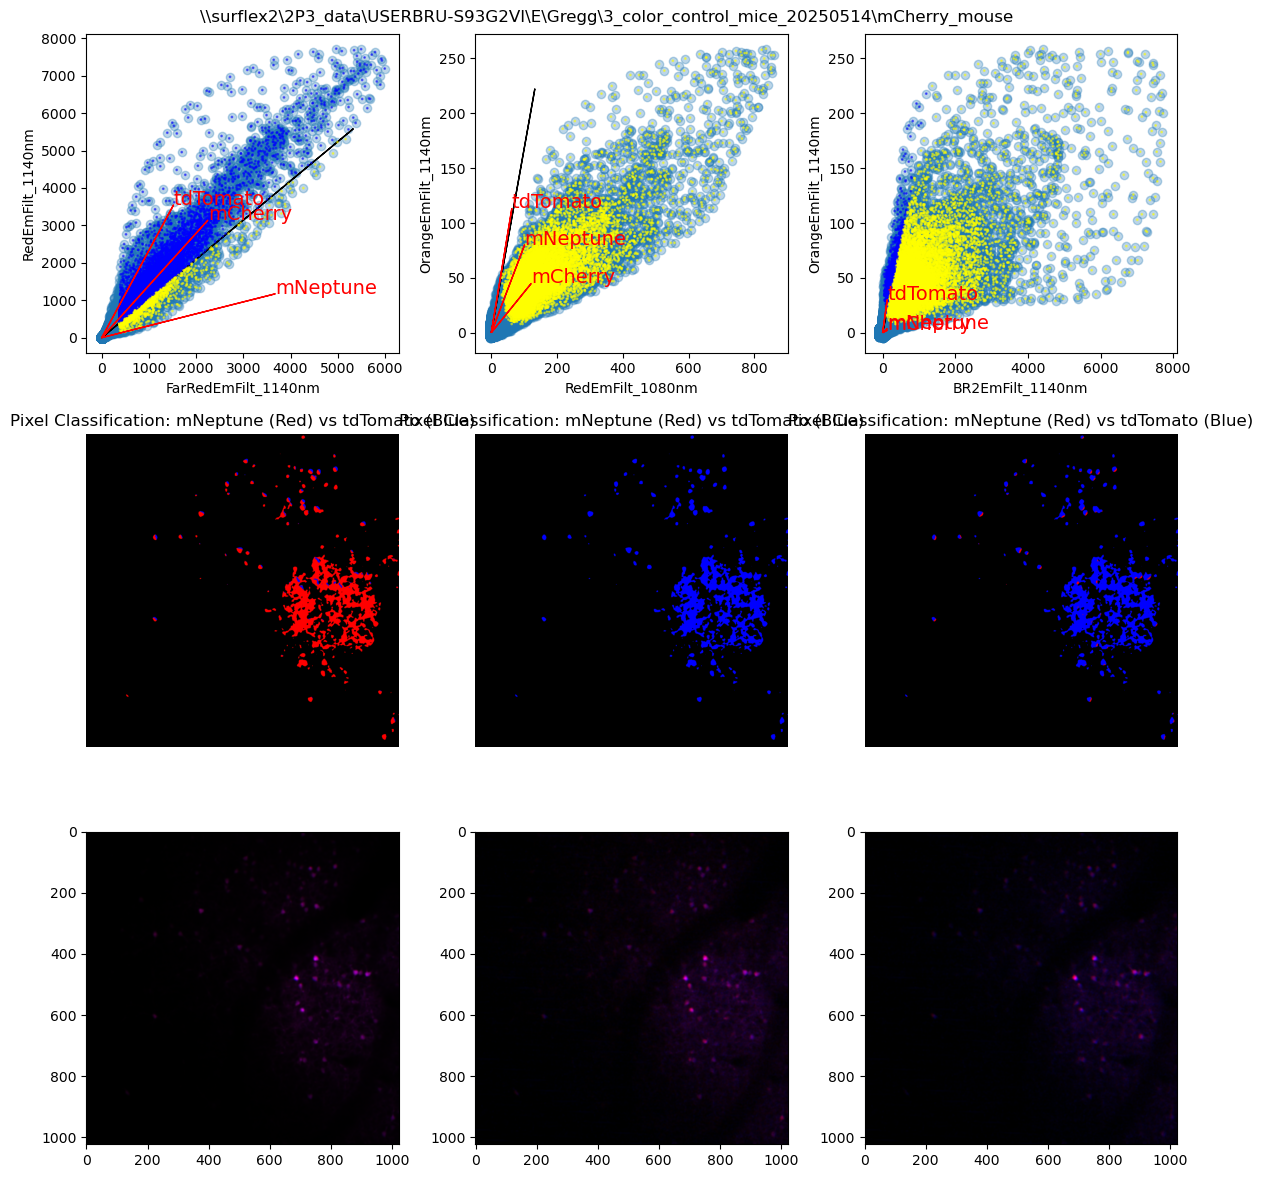

\\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_control_mice_20250514\mNeptune_mouse


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mNeptune: 0 points
tdTomato: 51210 points
mNeptune: 49454 points
tdTomato: 1756 points


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mNeptune: 50990 points
tdTomato: 220 points


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


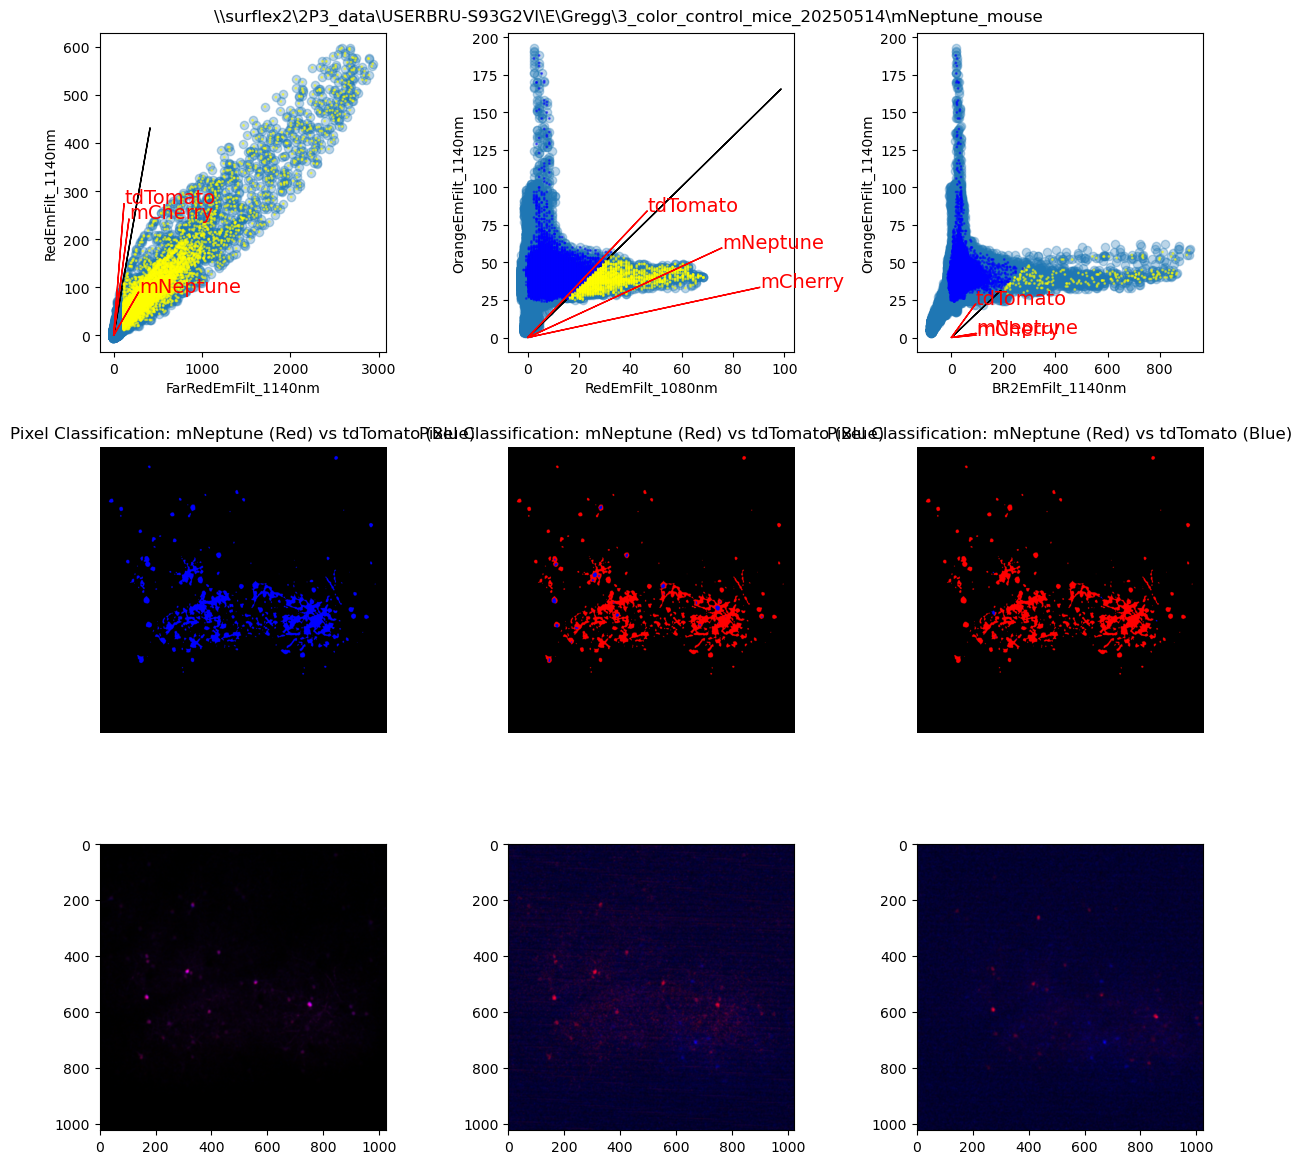

\\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_control_mice_20250514\tdTomato_mouse


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mNeptune: 51701 points
tdTomato: 52 points


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mNeptune: 41809 points
tdTomato: 9944 points


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mNeptune: 43055 points
tdTomato: 8698 points


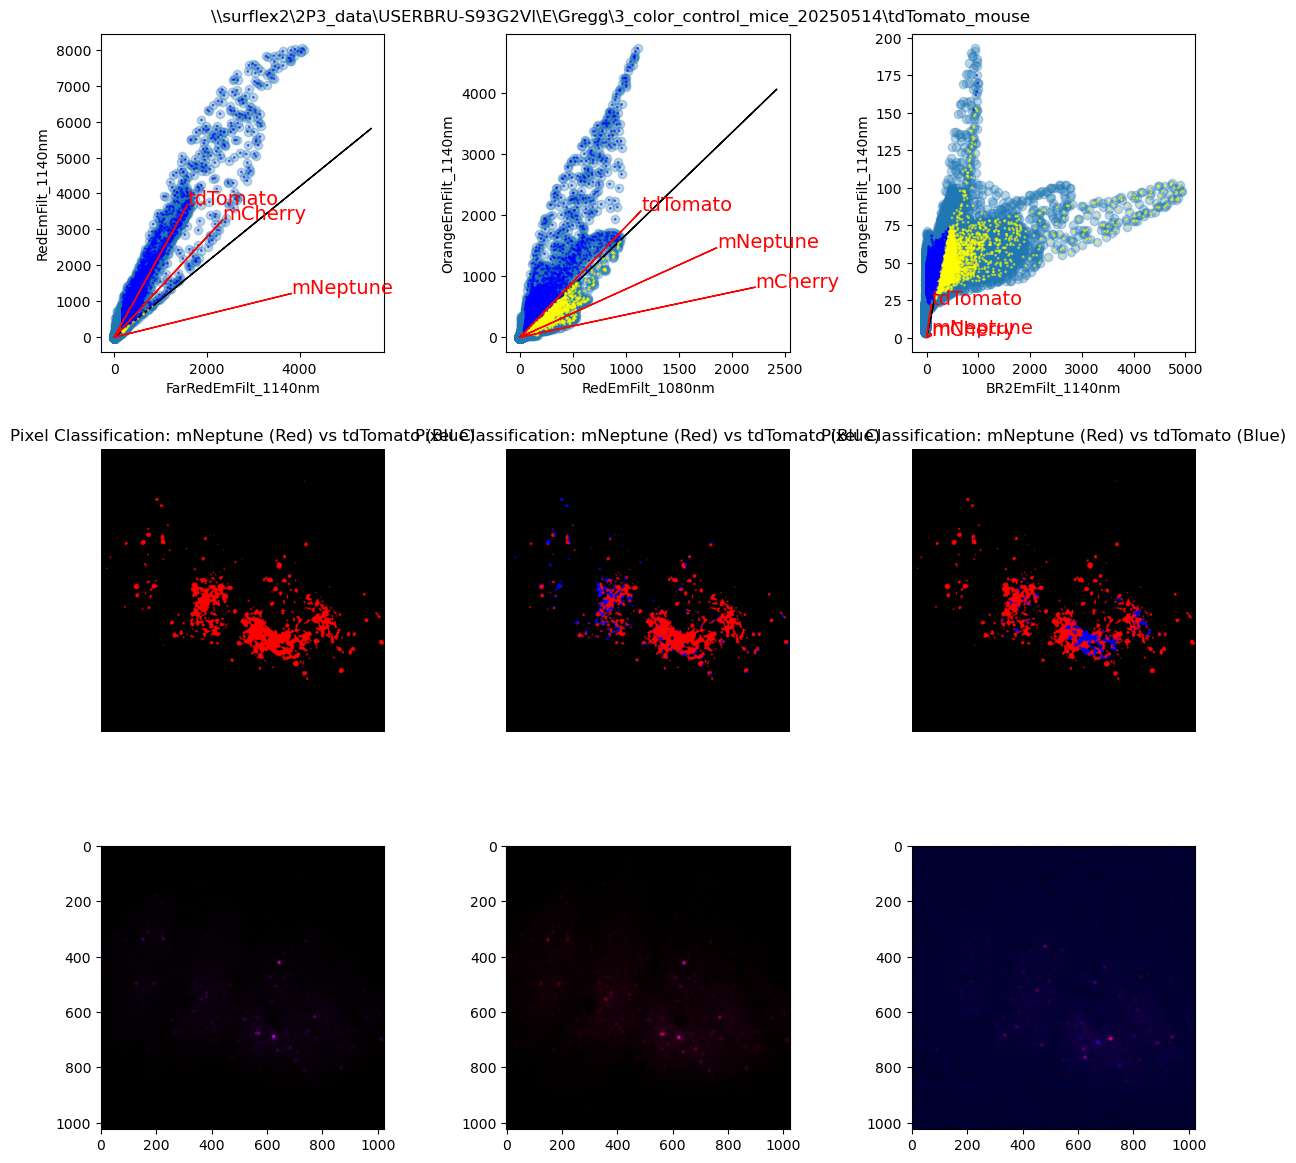

\\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_mice_20250422\exp94_animal2
Error processing \\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_mice_20250422\exp94_animal2: [WinError 123] The filename, directory name, or volume label syntax is incorrect: '\\\\surflex2\\2P3_data\\USERBRU-S93G2VI\\E\\Gregg\\3_color_mice_20250422\\exp94_animal2\\OrangeEmFilt_1140nm*\\*Ch1*.ome*'
\\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_mice_20250423\exp93.animal1\four_z_stacks_at_20mw
Error processing \\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_mice_20250423\exp93.animal1\four_z_stacks_at_20mw: [WinError 123] The filename, directory name, or volume label syntax is incorrect: '\\\\surflex2\\2P3_data\\USERBRU-S93G2VI\\E\\Gregg\\3_color_mice_20250423\\exp93.animal1\\four_z_stacks_at_20mw\\OrangeEmFilt_1140nm*\\*Ch1*.ome*'
\\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_mice_20250506\exp90_animal2\FOV1
Error processing \\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_mice_202505

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mNeptune: 12962 points
tdTomato: 140 points
Error processing \\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_mice_20250506\exp90_animal2\FOV3: [WinError 123] The filename, directory name, or volume label syntax is incorrect: '\\\\surflex2\\2P3_data\\USERBRU-S93G2VI\\E\\Gregg\\3_color_mice_20250506\\exp90_animal2\\FOV3\\OrangeEmFilt_1140nm*\\*Ch1*.ome*'
\\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_mice_20250506\exp94_animal2\FOV1


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mNeptune: 13030 points
tdTomato: 0 points
Error processing \\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_mice_20250506\exp94_animal2\FOV1: [WinError 123] The filename, directory name, or volume label syntax is incorrect: '\\\\surflex2\\2P3_data\\USERBRU-S93G2VI\\E\\Gregg\\3_color_mice_20250506\\exp94_animal2\\FOV1\\OrangeEmFilt_1140nm*\\*Ch1*.ome*'
\\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_mice_20250506\exp94_animal2\FOV2


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mNeptune: 13079 points
tdTomato: 0 points
Error processing \\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg\3_color_mice_20250506\exp94_animal2\FOV2: [WinError 123] The filename, directory name, or volume label syntax is incorrect: '\\\\surflex2\\2P3_data\\USERBRU-S93G2VI\\E\\Gregg\\3_color_mice_20250506\\exp94_animal2\\FOV2\\OrangeEmFilt_1140nm*\\*Ch1*.ome*'


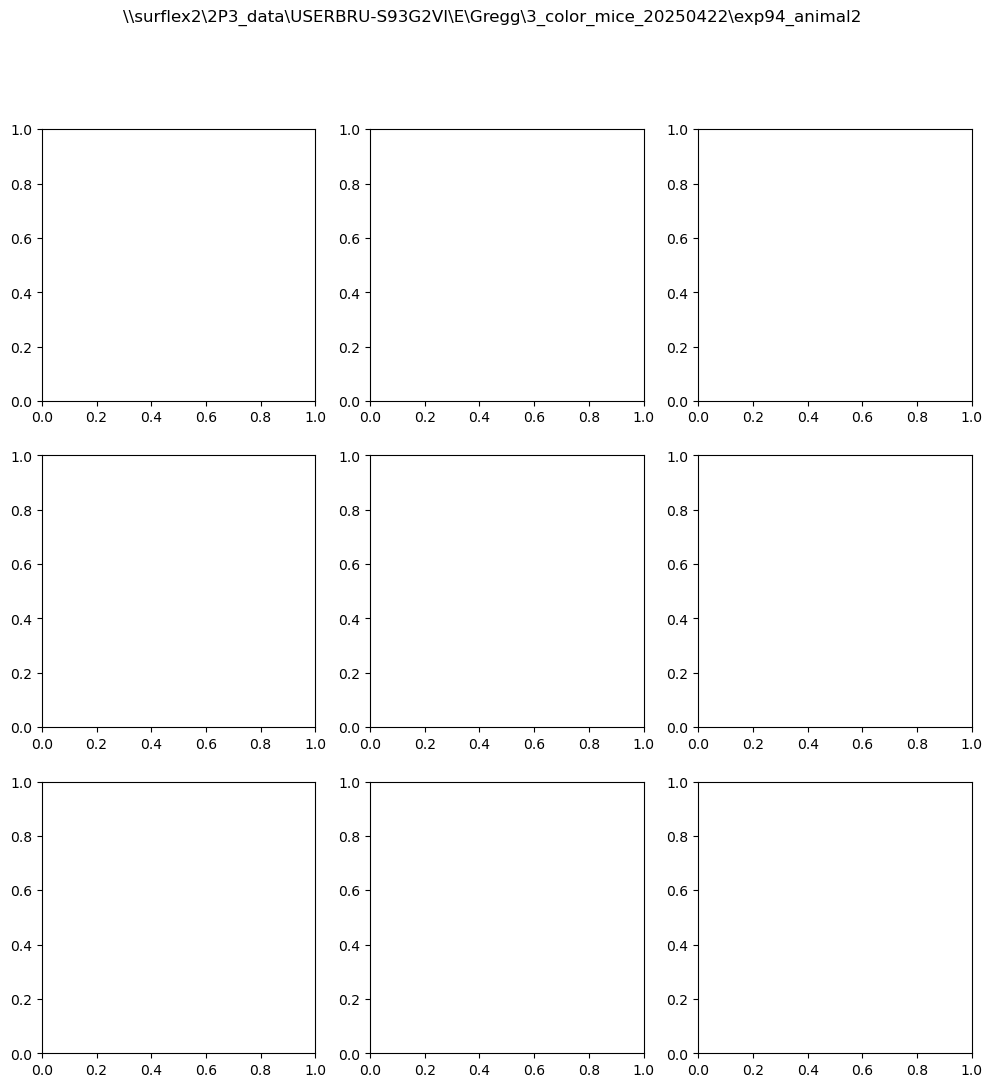

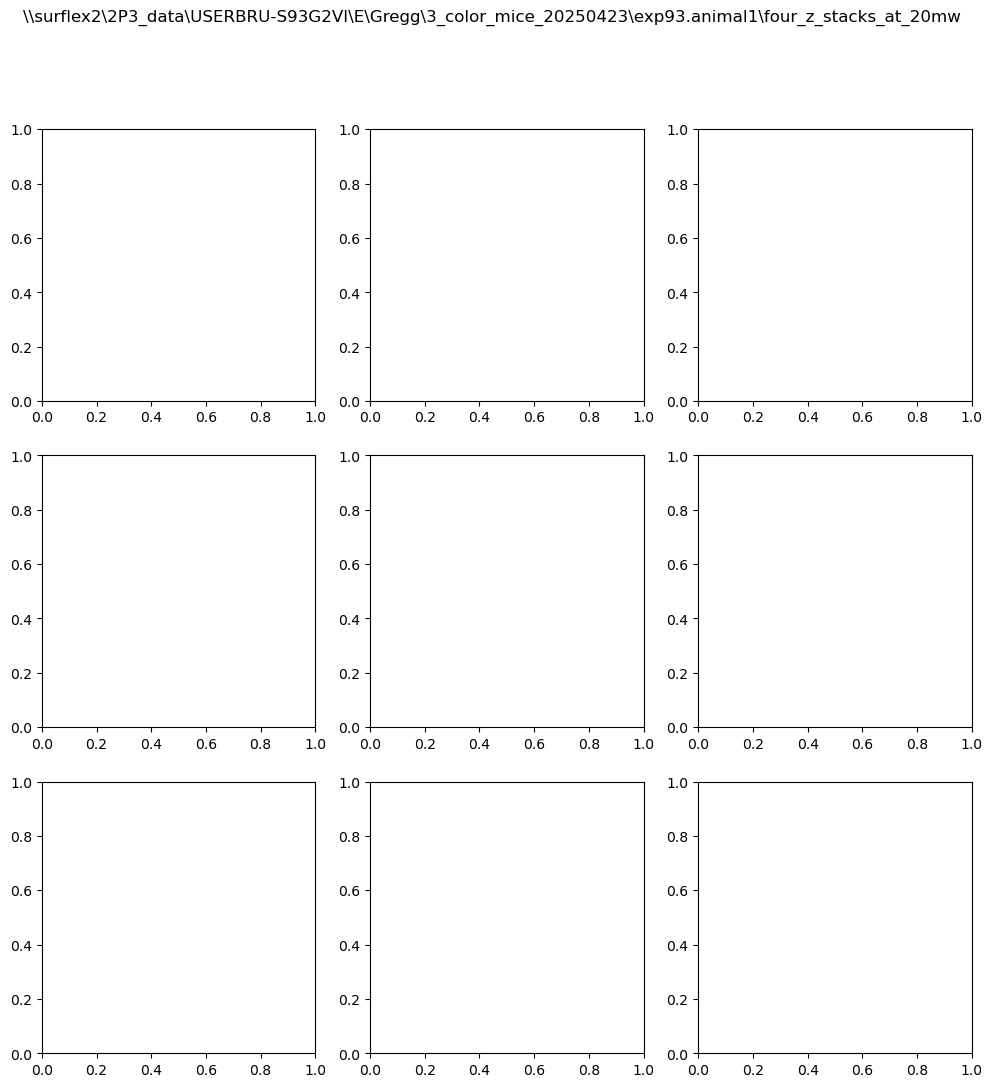

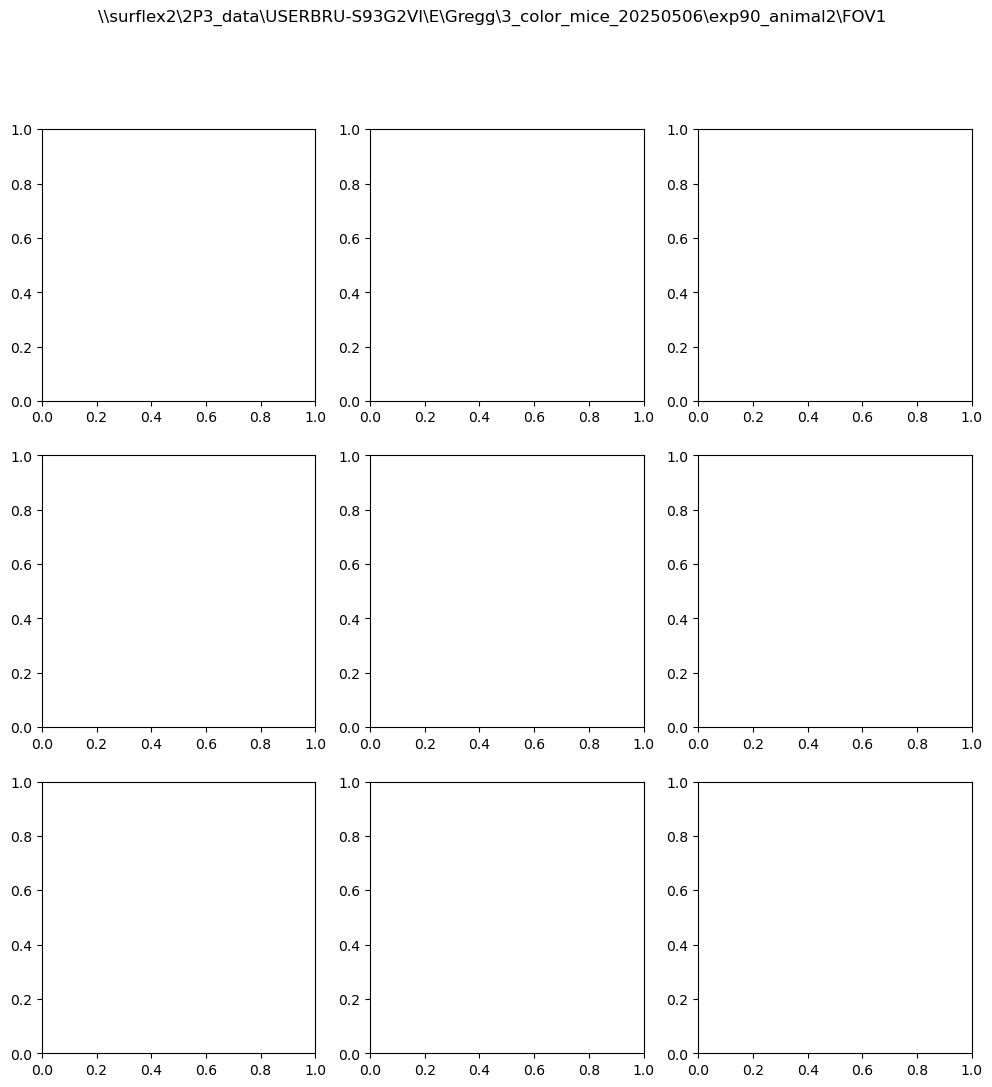

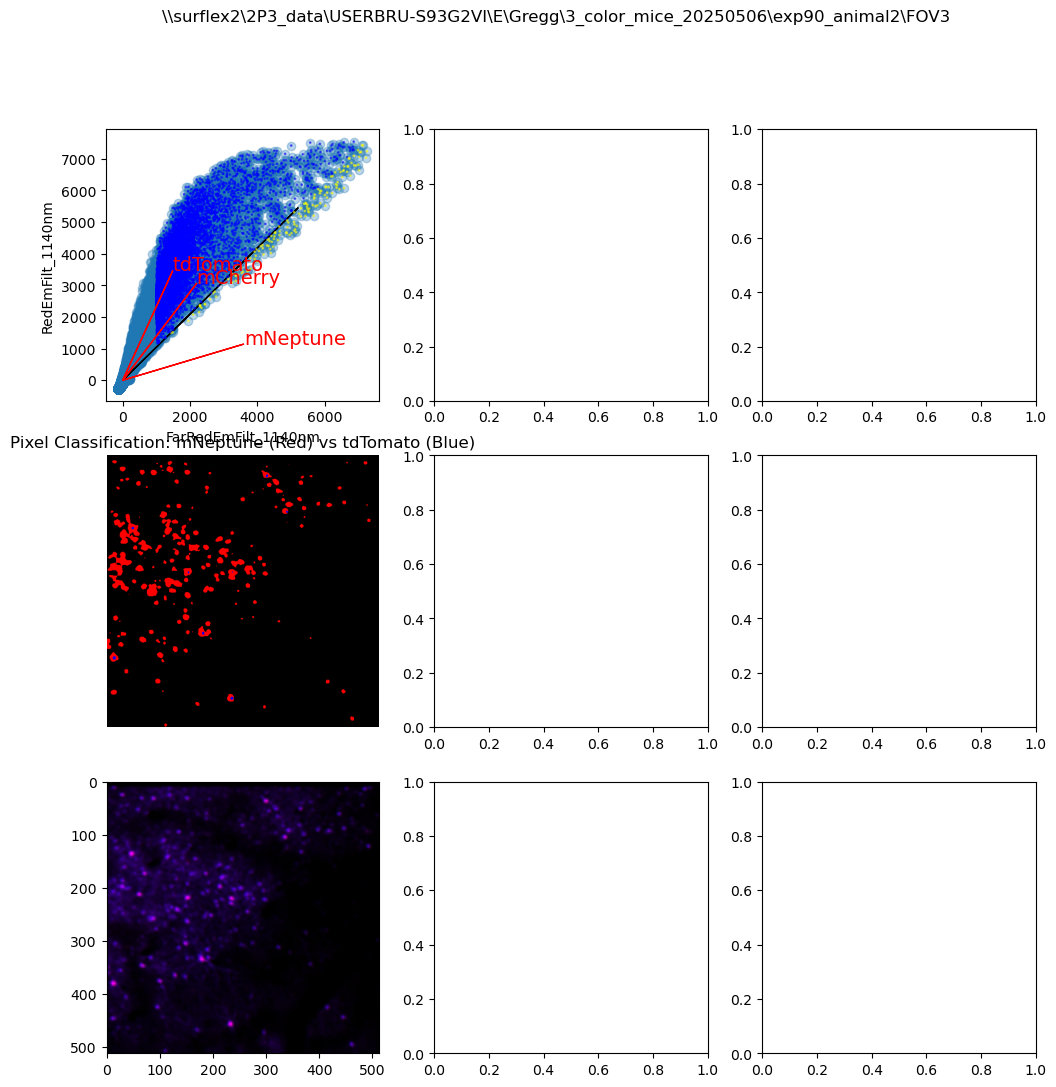

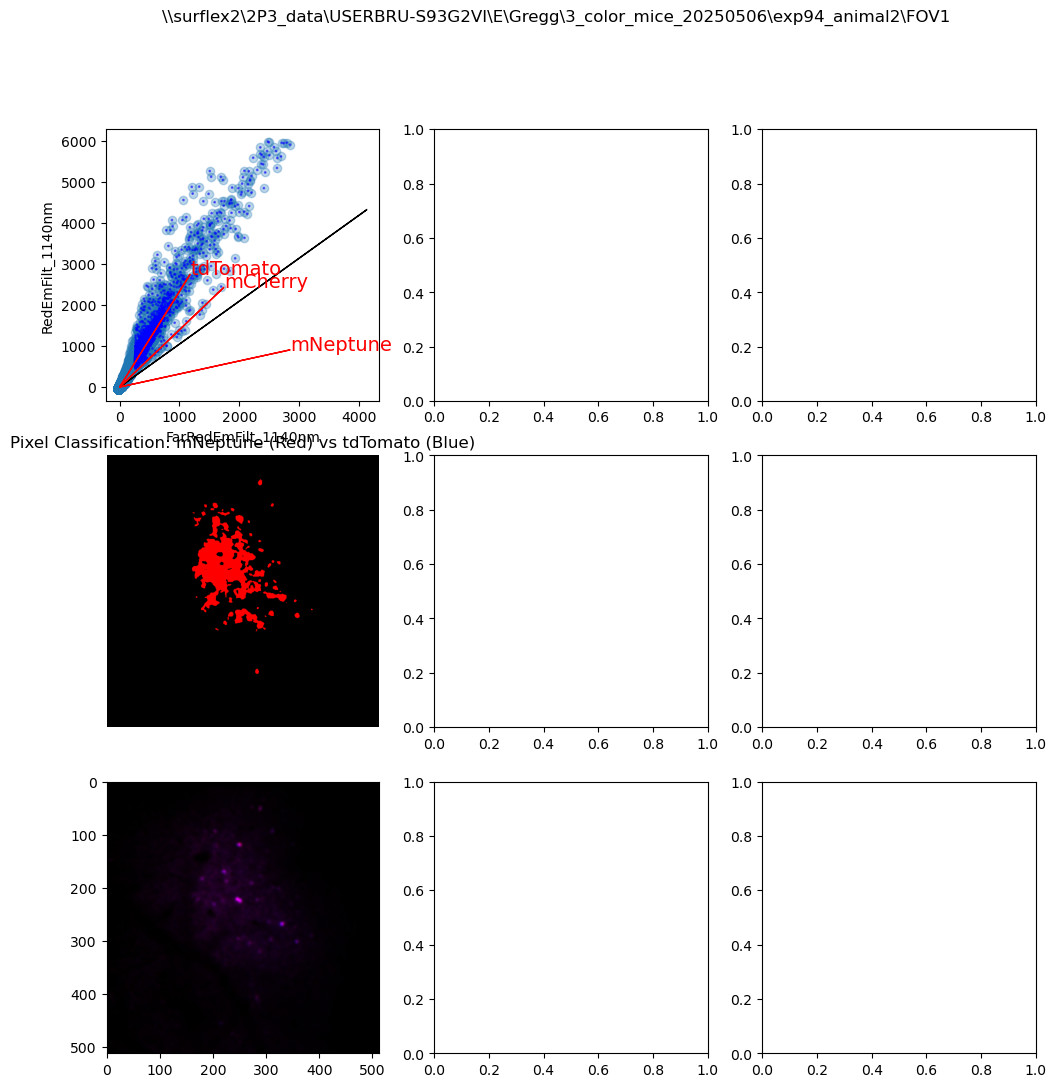

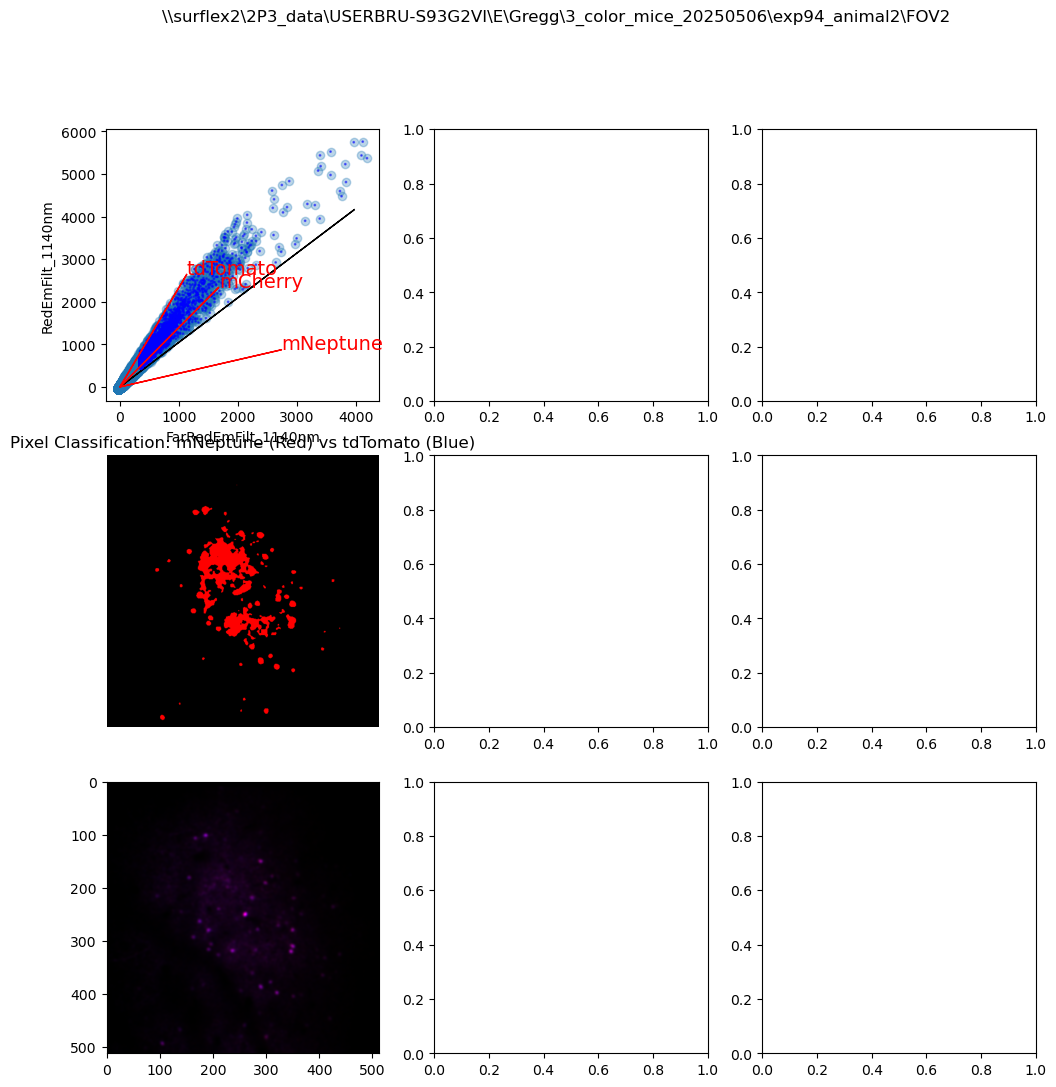

In [144]:
start_path = r"\\surflex2\2P3_data\USERBRU-S93G2VI\E\Gregg"
for dirpath, dirnames, filenames in os.walk(start_path):
    # Skip the root directory itself if needed
    try:
        plot_and_classify(dirpath)
    except Exception as e:
        print(f"Error processing {dirpath}: {e}")

In [ ]:
#sofie didn't have much luck with mine from 5/16 - we think I did the same mcherry mouse twice. 
#so we need to go back and do 4wavelenghts x 4 filters in all the mice
#also try to crank the power, just keep it the same across all of them
#want to try 760, whats going on??